# Reinforcement Learning for Molecular Lead Optimization
### Using ChEMBL Bioactivity Data

**Project:** This is a study of how Reinforcement Learning methods can contribute to molecular lead optimization. It is implemented as this: given a known inhibitor of EGFR, improve it by adding chemical groups one at a time. The modification is guided by a scoring function and an RL policy.

**RL Policies compared:**
- &#9898; Random Search (baseline — no learning)
- 🔵 Epsilon-Greedy Q-Learning
- 🔴 Triggered Epsilon-Greedy
- 🟢 UCB (Upper Confidence Bound)
- 🟣 Thompson Sampling

**Traditional baseline:**
- &#9899; QSAR Virtual Screening (rank existing ChEMBL library by predicted score)

**Target:** EGFR (CHEMBL203) — a well-studied cancer target with thousands of known compounds

---
**Runtime estimate:** ~2.5 hours with default settings

**To speed up:** In 'Imports & Configuration', reduce `episodes` to 200 and `random_seeds` to `[42]`

# Part 1 — Setup

*Dependencies, configuration, and a record of the machine this ran on.*


## 1. Install Dependencies


In [40]:
# ── INSTALL (run this first — takes ~1 minute) ──────────────
!pip install chembl-webresource-client rdkit scikit-learn -q
print('✓ Installation complete')

✓ Installation complete


## 2. Imports & Configuration


In [41]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import warnings
import random
warnings.filterwarnings('ignore')

from rdkit import Chem
from rdkit.Chem import Descriptors, QED, Crippen, AllChem
from rdkit.Chem import rdMolDescriptors, DataStructs, RWMol

# Suppress RDKit deprecation and info messages
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from chembl_webresource_client.new_client import new_client
from scipy import stats as _scipy_stats

import platform, sklearn
from rdkit import rdBase
import hashlib

print('✓ All imports successful')

# ── CONFIGURATION ── edit these to tune the experiment ──────
CONFIG = {
    # Data
    'target_chembl_id': 'CHEMBL203',   # EGFR cancer target
    'activity_type':    'IC50',
    'max_compounds':    6000,           # increased for larger, more diverse seed pool
    'fetch_random_seed': 42,            # seed for random compound sampling from ChEMBL
                                        # change to get a different representative sample

    # Training
    'episodes':         1000,           # from 200 to 1000 - larger pool benefits from more episodes
    'max_steps':        15,             # modifications per episode
    'eval_interval':    25,             # snapshot every N episodes
    # score_threshold is set dynamically in Cell 3c (after data fetch + QSAR build).
    # Formula: seed_pool_max + 2 × median_single_step_gain.
    # Rationale: threshold must require genuine multi-step optimisation, not just
    # a single lucky atom addition from a near-ceiling seed molecule.
    # Do not hardcode this value here — it depends on the seed pool and atom limit,
    # both of which can change between runs.
    'score_threshold':  None,  # populated by Cell 3c
    'pool_filter_cutoff': None,
    'pchembl_threshold': 7.5,   # raw pChEMBL potency gate — molecule must pass BOTH thresholds to count

    # Seeds — more seeds = more reliable results
    'random_seeds':     [42, 123, 456], #789, 135, 246, 357, 468, 579, 147], # restored seed 42 for fuller comparison

    # Triggered Epsilon-Greedy parameters — controls stagnation detection and reset behavior.
    # When best score hasn't improved by at least min_delta for patience episodes,
    # epsilon is reset to trigger_epsilon_reset to force re-exploration.
    # All four values are tunable without code changes.
    'trigger_patience':      200, # episodes without improvement before epsilon reset
    'trigger_epsilon_reset': 1.0, # epsilon value on reset (1.0 = full restart)
    'trigger_max_resets':    5,   # maximum number of resets allowed per seed run
    'trigger_min_delta':     0.0, # minimum score improvement to reset patience counter
                                  # 0.0 = any improvement counts, >0 = must exceed delta
    'trigger_w_perturb':     0.1, # W perturbation magnitude on reset, as fraction of W std dev
                                  # 0.0 = no perturbation (V026 behavior), 0.1 = 10% of std dev

    # Reward weights — how much each property matters
    'reward_weights': {
        'activity':   2.0,   # predicted pChEMBL binding
        'qed':        1.5,   # drug-likeness (0-1) — increased to create independent pChEMBL gate
        'lipinski':   1.5,   # Rule of Five compliance — increased to create independent pChEMBL gate
        'toxicity':  -2.0,   # penalty for toxic properties
    },

    # Q-learning hyperparameters
    'alpha':         0.1,    # learning rate
    'gamma':         0.99,   # discount factor (how much future rewards matter)

    # Epsilon-Greedy settings
    'epsilon_start': 1.0,    # start fully random
    'epsilon_end':   0.05,   # end nearly greedy
    'epsilon_decay': 0.995,  # how fast epsilon shrinks

    # UCB settings
    'ucb_c':         2.0,    # exploration coefficient (higher = more exploration)
    # n_bins removed — state is now raw 1027-dim Morgan+physicochemical vector
}

print('✓ Configuration loaded')
print(f"  Target:   {CONFIG['target_chembl_id']}")
print(f"  Budget:   {CONFIG['episodes']} episodes × {len(CONFIG['random_seeds'])} seeds")
print(f"  Compounds: up to {CONFIG['max_compounds']} from ChEMBL")

✓ All imports successful
✓ Configuration loaded
  Target:   CHEMBL203
  Budget:   1000 episodes × 3 seeds
  Compounds: up to 6000 from ChEMBL


# Part 2 — Data & Model

*Fetch the ChEMBL data, train the QSAR scorer, and verify the seed pool is reproducible.*


## 3. Load ChEMBL Data


In [42]:
# ── Load the EGFR bioactivity dataset ─────────────────────────
#
# If the first option cannot be obtained, the code will move to the next one etc.
#   1. data/egfr_chembl.parquet          — the snapshot these results came from
#   2. download it from the repo         — for Colab sessions opened via the badge
#   3. live fetch from ChEMBL            — a NEW experiment, not a reproduction

import os, json
from pathlib import Path

REPO_RAW_BASE = "https://raw.githubusercontent.com/farabhi/rl-lead-optimization/main"
DATA_DIR     = Path('data')
PARQUET_PATH = DATA_DIR / 'egfr_chembl.parquet'
PROV_PATH    = DATA_DIR / 'egfr_chembl.provenance.json'


def fetch_chembl_data(target_id, activity_type='IC50', limit=3000):
    print(f'Fetching ChEMBL data for {target_id}...')
    activity = new_client.activity
    results = activity.filter(
        target_chembl_id=target_id,
        standard_type=activity_type,
        relation='=',
        assay_type='B'  # binding
    ).only(['molecule_chembl_id', 'canonical_smiles', 'standard_value', 'pchembl_value'])
    total_available = len(results)
    print(f'  Total records available from ChEMBL: {total_available}')
    df = pd.DataFrame.from_records(list(results))
    print(f'  Records fetched: {len(df)}')
    df = df.dropna(subset=['canonical_smiles', 'pchembl_value'])
    df['pchembl_value'] = pd.to_numeric(df['pchembl_value'], errors='coerce')
    df = df[df['pchembl_value'] > 0].drop_duplicates(subset='canonical_smiles')

    def valid(smi):
        """Drop SMILES RDKit cannot parse. ChEMBL is curated but not perfect,
        and an unparseable entry would otherwise fail later inside scoring."""
        try:
            return Chem.MolFromSmiles(smi) is not None
        except Exception:
            return False

    df = df[df['canonical_smiles'].apply(valid)].reset_index(drop=True)
    print(f'  Valid compounds: {len(df)}')
    print(f'  pChEMBL range:   {df["pchembl_value"].min():.1f} – {df["pchembl_value"].max():.1f}')
    return df


def _write_provenance(n_records):
    """Stamp the ChEMBL release next to the data, so the version travels with it."""
    try:
        import requests
        st = requests.get('https://www.ebi.ac.uk/chembl/api/data/status.json',
                          timeout=30).json()
        release  = st.get('chembl_db_version', 'unknown')
        rel_date = st.get('chembl_release_date', 'unknown')
    except Exception as e:
        release, rel_date = 'unknown', 'unknown'
        print(f'  ! could not read ChEMBL release version: {e}')
    PROV_PATH.write_text(json.dumps({
        'chembl_release': release, 'chembl_release_date': rel_date,
        'fetched': pd.Timestamp.utcnow().isoformat()[:10],
        'target': CONFIG['target_chembl_id'], 'n_records': int(n_records),
        'committed': False,
        'note': 'Live fetch. Row order and release differ from the committed '
                'snapshot, so the sampled pool will not match published results.',
    }, indent=2))


# stale stats must not survive a dataset change
CONFIG['pool_filter_cutoff'] = None
CONFIG['score_threshold']    = None

DATA_DIR.mkdir(exist_ok=True)

if not PARQUET_PATH.exists() and REPO_RAW_BASE:
    try:
        import urllib.request
        print('Dataset not found locally — downloading the repository snapshot...')
        for p in (PARQUET_PATH, PROV_PATH):
            urllib.request.urlretrieve(f'{REPO_RAW_BASE}/data/{p.name}', p)
        print('  Downloaded.')
    except Exception as e:
        print(f'  Download failed ({e}) — will fetch from ChEMBL instead.')

if PARQUET_PATH.exists():
    df_full = pd.read_parquet(PARQUET_PATH)
    print(f'Loaded {len(df_full)} compounds from {PARQUET_PATH}')
else:
    df_full = fetch_chembl_data(CONFIG['target_chembl_id'],
                                CONFIG['activity_type'],
                                CONFIG['max_compounds'])
    df_full.to_parquet(PARQUET_PATH, index=False)
    _write_provenance(len(df_full))
    print(f'  Cached to {PARQUET_PATH}')
    print('  NOTE: this is a fresh fetch from the current ChEMBL release. It will '
          'NOT reproduce the published pool — see the provenance file.')

# ── Provenance, for the environment fingerprint ───────────────
if PROV_PATH.exists():
    _p = json.loads(PROV_PATH.read_text())
    DATA_PROVENANCE = (f"{_p.get('chembl_release', 'unknown')} "
                       f"({_p.get('chembl_release_date', '?')}), "
                       f"fetched {_p.get('fetched', '?')}")
else:
    DATA_PROVENANCE = 'unknown (no provenance record)'
print(f'  ChEMBL provenance: {DATA_PROVENANCE}')

# ── Working set: positional sample from the full dataset ──────
fetch_seed = CONFIG.get('fetch_random_seed', 42)
limit      = CONFIG['max_compounds']

if len(df_full) <= limit:
    df = df_full.copy()
    print(f'  Using all {len(df_full)} compounds (fewer than max_compounds={limit})')
else:
    df = df_full.sample(n=limit, random_state=fetch_seed).reset_index(drop=True)
    print(f'  Randomly sampled {limit} from {len(df_full)} available compounds '
          f'(fetch_random_seed={fetch_seed})')
print(f'  pChEMBL range: {df["pchembl_value"].min():.1f} – {df["pchembl_value"].max():.1f}')

print('\nSample compounds:')
df[['molecule_chembl_id', 'pchembl_value']].head(5)

Loaded 10138 compounds from data/egfr_chembl.parquet
  ChEMBL provenance: ChEMBL_36 (2025-07), fetched 2026-03
  Randomly sampled 6000 from 10138 available compounds (fetch_random_seed=42)
  pChEMBL range: 4.0 – 10.8

Sample compounds:


,molecule_chembl_id,pchembl_value
0,CHEMBL306029,5.72
1,CHEMBL571040,7.89
2,CHEMBL4083224,6.68
3,CHEMBL4297674,5.70
4,CHEMBL209818,5.94


## 4. Environment Fingerprint

Library versions and CPU SIMD support. Results are reproducible on a single machine but **not** across machines with different AVX-512 support, so this record is printed before anything else runs.


In [58]:
import importlib.metadata as md

print('=== ENVIRONMENT FINGERPRINT ===')
print('chembl     ', DATA_PROVENANCE)
print('numpy      ', np.__version__)
print('sklearn    ', sklearn.__version__)
print('rdkit      ', rdBase.rdkitVersion)
print('python     ', platform.python_version())

for p in ['pandas', 'scipy', 'matplotlib', 'chembl-webresource-client']:
    try:
        print(f'{p:<12}{md.version(p)}')
    except md.PackageNotFoundError:
        print(f'{p:<12}not installed')
try:
    cpu  = [l.split(':',1)[1].strip() for l in open('/proc/cpuinfo') if l.startswith('model name')][0]
    ncpu = sum(1 for l in open('/proc/cpuinfo') if l.startswith('processor'))
    print('\nCPU     ', cpu, f'({ncpu} threads)')
except Exception as e:
    print('cpu      n/a', e)
for v in ['OMP_NUM_THREADS','OPENBLAS_NUM_THREADS','MKL_NUM_THREADS']:
    print(f'{v:22s}', os.environ.get(v))
np.show_config()
print('=== END FINGERPRINT ===')

=== ENVIRONMENT FINGERPRINT ===
chembl      ChEMBL_36 (2025-07), fetched 2026-03
numpy       2.1.3
sklearn     1.6.1
rdkit       2026.03.5
python      3.13.15
pandas      2.2.3
scipy       1.16.3
matplotlib  3.10.0
chembl-webresource-client0.10.9

CPU      Intel(R) Xeon(R) CPU @ 2.20GHz (8 threads)
OMP_NUM_THREADS        None
OPENBLAS_NUM_THREADS   None
MKL_NUM_THREADS        None
Build Dependencies:
  blas:
    detection method: pkgconfig
    found: true
    include directory: /opt/_internal/cpython-3.13.0/lib/python3.13/site-packages/scipy_openblas64/include
    lib directory: /opt/_internal/cpython-3.13.0/lib/python3.13/site-packages/scipy_openblas64/lib
    name: scipy-openblas
    openblas configuration: OpenBLAS 0.3.27  USE64BITINT DYNAMIC_ARCH NO_AFFINITY
      Haswell MAX_THREADS=64
    pc file directory: /project/.openblas
    version: 0.3.27
  lapack:
    detection method: pkgconfig
    found: true
    include directory: /opt/_internal/cpython-3.13.0/lib/python3.13/site-packa

## 5. Build QSAR Model

Defines `compute_drug_score`, `smiles_to_fp` and `compute_diversity`.


In [ ]:
def smiles_to_fp(smiles, radius=2, nbits=1024):
    """Convert SMILES string to Morgan fingerprint (numerical descriptor)"""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=nbits)
    return np.array(fp, dtype=np.float32)

def check_lipinski(mol):
    """Lipinski Rule of Five — classic drug-likeness filter"""
    try:
        violations = sum([
            Descriptors.MolWt(mol)        > 500,
            Crippen.MolLogP(mol)          > 5,
            rdMolDescriptors.CalcNumHBD(mol) > 5,
            rdMolDescriptors.CalcNumHBA(mol) > 10,
        ])
        return 1.0 if violations <= 1 else 0.0
    except Exception:
        return 0.0

# ── Score cache — session-only ──────────────────────────────────────
# compute_drug_score() is called ~100,000+ times during training.
# Caching means each unique SMILES is only scored ONCE per session.
# Cache is intentionally NOT persisted to Drive — each session starts
# fresh to ensure novel molecules always get genuine QSAR scoring.
# Within a session, cache still speeds up cross-policy/cross-seed hits.
_score_cache = {}

def compute_drug_score(smiles, qsar_model):
    """
    Combined drug discovery score — reward signal for all RL agents.
    Results are cached by SMILES string to avoid redundant computation.
    """
    global _score_cache
    if smiles in _score_cache:
        return _score_cache[smiles]

    fp = smiles_to_fp(smiles)
    if fp is None:
        _score_cache[smiles] = -10.0
        return -10.0
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        _score_cache[smiles] = -10.0
        return -10.0
    try:
        activity  = qsar_model.predict([fp])[0]
        qed_score = QED.qed(mol)
        lip_score = check_lipinski(mol)
        logp      = Crippen.MolLogP(mol)
        mw        = Descriptors.MolWt(mol)
        tox       = max(0, (logp - 5) * 0.5) + max(0, (mw - 500) * 0.005)
        w = CONFIG['reward_weights']
        score = float(
            w['activity'] * activity +
            w['qed']      * qed_score +
            w['lipinski'] * lip_score +
            w['toxicity'] * tox
        )
    except Exception:
        score = -10.0

    _score_cache[smiles] = score
    return score

def clear_score_cache():
    """Call between policy runs if memory becomes a concern"""
    global _score_cache
    _score_cache = {}
    print('Score cache cleared')

def tanimoto_similarity(smi1, smi2):
    try:
        fp1 = AllChem.GetMorganFingerprintAsBitVect(Chem.MolFromSmiles(smi1), 2, 1024)
        fp2 = AllChem.GetMorganFingerprintAsBitVect(Chem.MolFromSmiles(smi2), 2, 1024)
        return DataStructs.TanimotoSimilarity(fp1, fp2)
    except Exception:
        return 0.0

def compute_diversity(smiles_list, sample=50):
    """
    Average pairwise Tanimoto distance of a molecule set.
    0 = all identical, 1 = all completely different.
    """
    sample_list = random.sample(smiles_list, min(sample, len(smiles_list)))
    fps = []
    for smi in sample_list:
        mol = Chem.MolFromSmiles(smi)
        if mol:
            fps.append(AllChem.GetMorganFingerprintAsBitVect(mol, 2, 1024))
    if len(fps) < 2:
        return 0.0
    sims = [DataStructs.TanimotoSimilarity(fps[i], fps[j])
            for i in range(len(fps)) for j in range(i+1, len(fps))]
    return 1.0 - np.mean(sims)

# ── Build the model ──────────────────────────────────────────
def build_qsar_model(df):
    print('Building QSAR model...')
    fps, labels = [], []
    for _, row in df.iterrows():
        fp = smiles_to_fp(row['canonical_smiles'])
        if fp is not None:
            fps.append(fp)
            labels.append(row['pchembl_value'])

    X, y = np.array(fps), np.array(labels)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = RandomForestRegressor(
        n_estimators=50,   # reduced from 150 — still accurate, ~3x faster inference
        max_depth=10,      # reduced from 12 — marginal accuracy loss, faster predict()
        min_samples_leaf=3, random_state=42, n_jobs=-1
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2   = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    print(f'  R² = {r2:.3f}  (1.0 = perfect; >0.6 = usable)')
    print(f'  RMSE = {rmse:.3f} pChEMBL units')
    print(f'  Trained on {len(X_train)} compounds')

    # Pre-warm the cache with all training + test molecules
    # These will definitely be visited as seed molecules during RL
    print('  Pre-warming score cache with known compounds...')
    for smi in df['canonical_smiles']:
        compute_drug_score(smi, model)
    print(f'  Cache pre-warmed: {len(_score_cache)} molecules scored')
    return model

qsar_model = build_qsar_model(df)
print('✓ QSAR model ready')

Building QSAR model...
  R² = 0.580  (1.0 = perfect; >0.6 = usable)
  RMSE = 0.899 pChEMBL units
  Trained on 4800 compounds
  Pre-warming score cache with known compounds...
  Cache pre-warmed: 6000 molecules scored
✓ QSAR model ready


## 6. Pipeline Helpers

Shared functions used by the experiment, the analysis and the diagnostics — defined once, so no downstream cell depends on a diagnostic or plotting cell having been run first.


In [ ]:
# ── Pipeline helpers ─────────────────────────────────────────
# Shared functions used by the experiment, the analysis and the
# diagnostics. Defined once here so no downstream cell depends on
# a diagnostic or plotting cell having been run.

def build_seed_slice(df):
    """Middle 50% by pChEMBL. Sort key must be TOTAL: pchembl_value has ~5400
    ties across 6000 rows, and a positional slice over a partially-ordered key
    selects an arbitrary subset that varies with the sort implementation."""
    ds = df.sort_values(['pchembl_value', 'canonical_smiles'])
    n  = len(ds)
    return ds.iloc[n // 4 : 3 * n // 4]['canonical_smiles'].tolist()


def build_seed_scores(df, qsar_model, filter_cutoff=None):
    """SMILES -> composite score for every molecule in the seed pool.

    The same pool the experiment trains on: the total-sorted middle slice,
    filtered to compounds below the pool cutoff. Reads CONFIG at CALL time,
    so it must be called after the dynamic-threshold cell has run. Scores
    come from the cache, so repeat calls are cheap.
    """
    if filter_cutoff is None:
        filter_cutoff = CONFIG.get('pool_filter_cutoff', CONFIG['score_threshold'])
    pool = [smi for smi in build_seed_slice(df)
            if compute_drug_score(smi, qsar_model) < filter_cutoff]
    return {smi: compute_drug_score(smi, qsar_model) for smi in pool}


def aggregate(results_list, key):
    """Average a metric across seeds -> (mean, std)"""
    curves  = [r[key] for r in results_list]
    min_len = min(len(c) for c in curves)
    curves  = [c[:min_len] for c in curves]
    return np.mean(curves, axis=0), np.std(curves, axis=0)


def top_molecules(results_list, n=50):
    pool = []
    for r in results_list:
        pool.extend(r['all_molecules'])
    seen, unique = set(), []
    for smi, score in sorted(pool, key=lambda x: x[1], reverse=True):
        if smi not in seen:
            seen.add(smi)
            unique.append((smi, score))
    return unique[:n]


def summary_stats(results_list):
    top    = top_molecules(results_list, 50)
    scores = [s for _, s in top]
    smiles = [s for s, _ in top]
    eps    = [r['episodes_to_threshold'] for r in results_list if r['threshold_reached']]
    return {
        'max_score':       max(scores) if scores else 0,
        'mean_top50':      np.mean(scores) if scores else 0,
        'std_top50':       np.std(scores)  if scores else 0,
        'above_threshold': sum(1 for s in scores if s >= CONFIG['score_threshold']),
        'diversity':       compute_diversity(smiles),
        'success_rate':    sum(r['episodes_to_threshold'] is not None for r in results_list) / len(results_list),
        'mean_episodes':   np.mean(eps) if eps else None,
        'std_episodes':    np.std(eps)  if eps else None,
    }


## 7. Pool Integrity Check

Confirms the sort key is total and the extracted slice matches a recorded reference hash. A `[FAIL]` here means pool composition is still platform-dependent and cross-run comparisons cannot be trusted.


In [ ]:
EXPECTED_SLICE_HASH = '8b8f23e889de7c447be3aa535de694b8'
#EXPECTED_SLICE_HASH = None   # paste the hash from the first post-fix run

print('=== POOL INTEGRITY ===')
print('len(df):', len(df))
print('dup pchembl values:', int(df['pchembl_value'].duplicated().sum()))

# Check 1 — TOTALITY (self-verifying, no reference needed)
dup_key = int(df.duplicated(subset=['pchembl_value', 'canonical_smiles']).sum())
print('dup composite keys:', dup_key)
if dup_key == 0:
    print('  [PASS] sort key is total — exactly one valid ordering exists')
else:
    print(f'  [PASS] {dup_key} composite-key ties remain, but they share canonical_smiles,')
    print('         so the extracted SMILES list is identical under any permutation')

# Check 2 — REPRODUCIBILITY (cross-host)
# Validate the SAME function the pipeline uses — never a hand-copied duplicate,
# or this check can pass while the real slice logic has drifted.
sl = build_seed_slice(df)
h  = hashlib.md5('|'.join(sl).encode()).hexdigest()
print('slice size:', len(sl))
print('slice hash:', h)
if EXPECTED_SLICE_HASH is None:
    print('  [BASELINE] no reference set — record this hash as EXPECTED_SLICE_HASH')
elif h == EXPECTED_SLICE_HASH:
    print('  [PASS] slice matches reference — pool is reproducible on this host')
else:
    print(f'  [FAIL] slice differs from reference {EXPECTED_SLICE_HASH}')
    print('         pool composition is still platform-dependent — do not trust cross-run comparisons')
print('=== END POOL INTEGRITY ===')

=== POOL INTEGRITY ===
len(df): 6000
dup pchembl values: 5424
dup composite keys: 0
  [PASS] sort key is total — exactly one valid ordering exists
slice size: 3000
slice hash: 8b8f23e889de7c447be3aa535de694b8
  [PASS] slice matches reference — pool is reproducible on this host
=== END POOL INTEGRITY ===


## 8. Score Distribution Diagnostic

What is the ceiling of the composite drug score in this dataset? Verifies the configured threshold is actually reachable.


Scoring all ChEMBL compounds with composite drug score...
(This uses the same weighted formula the RL agents optimise)

  Compounds scored:      6000
  Max composite score:   20.521  ← hard ceiling for all methods
  90th percentile:       17.618
  75th percentile:       16.525
  Mean:                  14.881

  Composite score threshold: None  (used by RL agents)
  pChEMBL threshold:         7.5  (potency reporting only)
  Composite score threshold: not yet set (Cell 3c sets it dynamically)

  Run Cell 3c to set the dynamic threshold, then re-run this cell if needed.


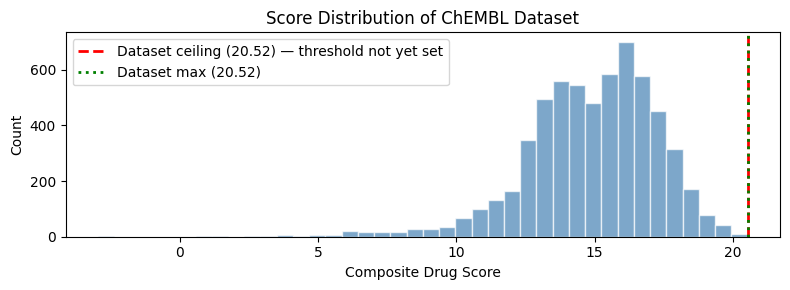

✓ Diagnostic complete

Heavy atom count distribution (seed pool = middle 50% by pChEMBL):

  Min:    12
  Median: 35
  Mean:   34.6
  95th pct: 46
  Max:    84
  Max reachable with 15 steps: 99  (well within drug-like range)


In [ ]:
# ── DIAGNOSTIC: What is the ceiling of the composite drug score in this dataset? ──
# Run this after Cell 3 (fetch data) and Cell 4 (build QSAR model)
# to verify the threshold in CONFIG is actually reachable.

print('Scoring all ChEMBL compounds with composite drug score...')
print('(This uses the same weighted formula the RL agents optimise)')
print()

diag_scores = []
for smi in df['canonical_smiles']:
    s = compute_drug_score(smi, qsar_model)
    if s > -10.0:
        diag_scores.append(s)

import numpy as np
diag_scores = sorted(diag_scores, reverse=True)

print(f'  Compounds scored:      {len(diag_scores)}')
print(f'  Max composite score:   {max(diag_scores):.3f}  ← hard ceiling for all methods')
print(f'  90th percentile:       {np.percentile(diag_scores, 90):.3f}')
print(f'  75th percentile:       {np.percentile(diag_scores, 75):.3f}')
print(f'  Mean:                  {np.mean(diag_scores):.3f}')
print()
print(f'  Composite score threshold: {CONFIG["score_threshold"]}  (used by RL agents)')
print(f'  pChEMBL threshold:         {CONFIG["pchembl_threshold"]}  (potency reporting only)')

# CONFIG['score_threshold'] is None at this point — it gets set dynamically
# in Cell 3c which runs after this cell. We use the dataset max as a proxy
# here just for the diagnostic printout.
threshold_for_diag = CONFIG['score_threshold'] if CONFIG['score_threshold'] is not None                      else max(diag_scores)
n_above = sum(1 for s in diag_scores if s >= threshold_for_diag)
pct_above = 100 * n_above / len(diag_scores)
if CONFIG['score_threshold'] is None:
    print(f'  Composite score threshold: not yet set (Cell 3c sets it dynamically)')
else:
    print(f'  Compounds above composite threshold: {n_above} ({pct_above:.1f}%)')
print()

if CONFIG['score_threshold'] is not None:
    if max(diag_scores) < CONFIG['score_threshold']:
        print('  ⚠️  WARNING: composite threshold exceeds dataset ceiling — no method can reach it.')
        print(f'     Recommended threshold: {max(diag_scores)*0.95:.2f} (95% of max)')
    elif pct_above < 1.0:
        print('  ⚠️  Composite threshold is in the top 1% — reachable but challenging.')
    else:
        print('  ✓  Composite threshold is achievable — experiment should show differentiation between policies.')
else:
    print('  Run Cell 3c to set the dynamic threshold, then re-run this cell if needed.')

# Quick histogram
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(diag_scores, bins=40, color='steelblue', alpha=0.7, edgecolor='white')
# Draw threshold line — red if threshold is set (Cell 3c has run), otherwise
# draw the dataset ceiling in red with a different label so the plot is still
# informative. Re-run this cell after Cell 3c to see the proper threshold line.
if CONFIG['score_threshold'] is not None:
    ax.axvline(CONFIG['score_threshold'], color='red', linestyle='--',
               linewidth=2, label=f'Threshold ({CONFIG["score_threshold"]})')
else:
    ax.axvline(max(diag_scores), color='red', linestyle='--',
               linewidth=2, label=f'Dataset ceiling ({max(diag_scores):.2f}) — threshold not yet set')
ax.axvline(max(diag_scores), color='green', linestyle=':',
           linewidth=2, label=f'Dataset max ({max(diag_scores):.2f})')
ax.set_xlabel('Composite Drug Score')
ax.set_ylabel('Count')
ax.set_title('Score Distribution of ChEMBL Dataset')
ax.legend()
plt.tight_layout()
plt.show()
print('✓ Diagnostic complete')

# ── Heavy atom count distribution (informational) ────────────
# No explicit heavy atom limit in V018 — the MW/toxicity penalty in the
# composite score discourages oversized molecules, and the 15-step budget
# caps growth at +15 atoms from the starting molecule. This section is
# kept for reference to understand the seed pool size distribution.
print()
print('Heavy atom count distribution (seed pool = middle 50% by pChEMBL):')
print()

seed_smiles_diag = build_seed_slice(df)
ha_counts = []
for smi in seed_smiles_diag:
    mol = Chem.MolFromSmiles(smi)
    if mol:
        ha_counts.append(mol.GetNumHeavyAtoms())
ha_counts = np.array(ha_counts)

print(f'  Min:    {ha_counts.min()}')
print(f'  Median: {int(np.median(ha_counts))}')
print(f'  Mean:   {ha_counts.mean():.1f}')
print(f'  95th pct: {int(np.percentile(ha_counts, 95))}')
print(f'  Max:    {ha_counts.max()}')
print(f'  Max reachable with 15 steps: {ha_counts.max() + 15}  (well within drug-like range)')

# Part 3 — Environment & Policies

*The molecular environment, the derived success threshold, and the five exploration policies.*


## 9. Molecular Environment


In [ ]:
# ── State cache — eliminates redundant descriptor computation ──
# smiles_to_state() computes MolWt, LogP and QED on every step, over the same
# molecules the score cache already sees, so the resulting state vector is
# cached by SMILES as well.
#
# State = 1024-bit Morgan fingerprint + 3 normalised physicochemical scalars
# (MW, LogP, QED). Morgan encodes substructure identity; scalars give the
# policy direct visibility into the properties that drive the reward.
#
# KNOWN GAP — predicted activity is NOT in the state, and probably should be.
# The reward is 2.0*activity + 1.5*QED + 1.5*Lipinski - 2.0*toxicity. QED is
# here directly; toxicity is a function of LogP and MW, which are here; two of
# the Lipinski criteria are here. The QSAR activity term - the LARGEST single
# weight - is the one component the policy cannot see.
#
# It looks redundant to add it, since the QSAR model's own input is the Morgan
# fingerprint and that is already in the state. But the QSAR model is a random
# forest (deeply non-linear) while the policy is a LINEAR map over the same
# bits. A linear function cannot reconstruct a forest's output from the
# forest's inputs, so the information is present in principle and unusable in
# practice. The policy is asked to maximise something while blind to the
# heaviest part of it.
#
# v2: add predicted activity as a 1028th feature. Cheap (compute_drug_score
# already calls the model, and states are cached by SMILES) and NOT reward
# leakage - the policy would see the CURRENT molecule's predicted activity,
# exactly as it already sees the current QED, not the post-action reward.
# Testable either way: if it moves the needle the bottleneck was feature
# visibility; if it does not, the bottleneck is the single shared weight
# matrix, which argues for per-scaffold representation over feature work.
STATE_DIM = 1027  # 1024 Morgan bits + MW + LogP + QED
_state_cache = {}

def smiles_to_state(smiles):
    global _state_cache
    if smiles in _state_cache:
        return _state_cache[smiles]
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        _state_cache[smiles] = np.zeros(STATE_DIM, dtype=np.float32)
        return _state_cache[smiles]
    try:
        fp   = AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=1024)
        fp   = np.array(fp, dtype=np.float32)
        mw   = np.float32(min(Descriptors.MolWt(mol), 800) / 800)
        logp = np.float32(np.clip((Crippen.MolLogP(mol) + 5) / 15, 0, 1))
        qed  = np.float32(QED.qed(mol))
        s    = np.concatenate([fp, [mw, logp, qed]])
    except Exception:
        s = np.zeros(STATE_DIM, dtype=np.float32)
    _state_cache[smiles] = s
    return s


class MoleculeEnv:
    """
    Drug discovery RL environment — optimized for speed.
    Key changes vs original:
      - State computed once per SMILES via cache (not re-parsed every step)
      - Current score stored as instance variable (no double scoring in step)
      - Atom size check done before sanitization (fast early exit)
    """

    MODIFICATIONS = [
        ('add_methyl',   6,  'C'),
        ('add_hydroxyl', 8,  'O'),
        ('add_fluorine', 9,  'F'),
        ('add_nitrogen', 7,  'N'),
        ('add_chlorine', 17, 'Cl'),
        ('add_sulfur',   16, 'S'),
    ]

    def __init__(self, seed_smiles, qsar_model, max_steps=15, rng=None):
        self.seed_smiles   = seed_smiles
        self.qsar_model    = qsar_model
        self.max_steps     = max_steps
        self.n_actions     = len(self.MODIFICATIONS)
        self.n_states      = STATE_DIM  # input dim for linear function approximator
        self.current_score = 0.0   # stored — avoids double scoring in step()
        # Separate RNG — env choices are independent from policy's random state
        self.rng           = rng or random.Random()

    def reset(self, start_smiles=None):
        # Hook for policy-chosen starting molecules. The policies each implement
        # a select_seed() method, but the training loop never calls it and never
        # passes start_smiles — so in practice every episode starts from a
        # uniformly random draw, identical across all policies.
        if start_smiles is not None:
            self.current_smiles = start_smiles
        else:
            self.current_smiles = self.rng.choice(self.seed_smiles)
        self.steps          = 0
        self.current_score  = compute_drug_score(self.current_smiles, self.qsar_model)
        self.best_score     = self.current_score
        self.best_smiles    = self.current_smiles
        return smiles_to_state(self.current_smiles)

    def _apply_modification(self, smiles, action_idx):
        """Apply chemical modification. Returns new SMILES or None.

        No explicit heavy atom limit — the MW/toxicity penalty in compute_drug_score
        discourages oversized molecules via the reward signal, and the 15-step budget
        caps growth at +15 atoms from the starting molecule (seed pool median ~30 atoms,
        so worst case ~45 atoms — well within drug-like range).
        """
        _, atomic_num, _ = self.MODIFICATIONS[action_idx]
        try:
            mol = RWMol(Chem.MolFromSmiles(smiles))
            if mol is None:
                return None
            # Attachable = has spare valence. RDKit tracks implicit H as a derived
            # count (allowed valence - explicit bonds), so no H is literally
            # removed: AddBond consumes the free slot and SanitizeMol recomputes
            # the count. Formally this is H->R substitution.
            # Using implicit H avoids the prior bug where ring-heavy EGFR
            # scaffolds showed no valid candidates and nearly every modification
            # failed sanitization.
            #
            # NOTE - this filter is purely valence-based, with no atom-type check,
            # so heteroatoms with an implicit H are valid targets too. Attaching O
            # to an N-H gives a hydroxylamine, N to an S-H gives a sulfenamide, O
            # to an O-H gives a peroxide. Those are exactly the implausible motifs
            # that show up among top-scoring molecules: the reward does not penalise
            # them (nothing encodes stability) and the action space does not prevent
            # them. v2: restrict candidate sites by atom type, or blacklist new-bond
            # pairs (O-O, N-O, N-N, S-N). Far cheaper than a synthesizability model.
            candidates = [a.GetIdx() for a in mol.GetAtoms()
                          if a.GetNumImplicitHs() > 0]
            if not candidates:
                return None
            attach = self.rng.choice(candidates)
            new_i  = mol.AddAtom(Chem.Atom(atomic_num))
            mol.AddBond(attach, new_i, Chem.BondType.SINGLE)
            Chem.SanitizeMol(mol)
            return Chem.MolToSmiles(mol)
        except Exception:
            return None

    def step(self, action):
        new_smiles = self._apply_modification(self.current_smiles, action)
        self.steps += 1

        if new_smiles is None:
            # Invalid modification — penalize, stay on current molecule
            reward = -0.5
            info   = {'smiles': self.current_smiles,
                      'score':  self.best_score, 'valid': False}
        else:
            new_score = compute_drug_score(new_smiles, self.qsar_model)
            reward    = new_score - self.current_score  # ← no double scoring
            self.current_score  = new_score
            self.current_smiles = new_smiles
            if new_score > self.best_score:
                self.best_score  = new_score
                self.best_smiles = new_smiles
            info = {'smiles': self.best_smiles,
                    'score':  self.best_score, 'valid': True}

        next_state = smiles_to_state(self.current_smiles)
        done       = self.steps >= self.max_steps
        return next_state, reward, done, info


print('✓ Environment defined')
print(f'  Action space: {[m[0] for m in MoleculeEnv.MODIFICATIONS]}')

✓ Environment defined
  Action space: ['add_methyl', 'add_hydroxyl', 'add_fluorine', 'add_nitrogen', 'add_chlorine', 'add_sulfur']


## 10. Dynamic Score Threshold

The success threshold is derived from the pool, so any change in pool composition moves it.


In [ ]:
import random as _random  # local alias — avoids shadowing the module before full imports


def estimate_score_threshold(df, qsar_model, config, n_sample=150, factor=2.0,
                              pool_filter_percentile=90):
    """
    Computes a data-driven score threshold requiring genuine multi-step
    optimisation, using a two-pass approach to break the circular dependency.

    THE CIRCULAR DEPENDENCY PROBLEM (V017 bug):
    --------------------------------------------
    The training loop filters out seed molecules already above the threshold
    (so agents can't trivially 'find' a good candidate by lucky reset). But
    we need the threshold to know what to filter, and we need the filtered
    pool to compute the threshold. In V017, we skipped this filter in Cell 3c,
    which left outlier compounds (e.g. score=20.502) in the pool. Their presence
    inflated seed_pool_max, pushing the threshold to 20.97 — unreachable in
    practice since the outlier itself was the ceiling and couldn't be improved.

    THE TWO-PASS SOLUTION:
    ----------------------
    Pass 1: Use the Nth percentile of ALL scored compounds from Cell 3b
            (default: 90th percentile) as a conservative initial filter.
            This removes clear outliers without needing a final threshold.
    Pass 2: Build the filtered seed pool (middle 50% by pChEMBL, compounds
            above the Pass 1 cutoff excluded), compute seed_pool_max and
            median single-step gain from THIS clean pool, then apply the
            formula: threshold = seed_pool_max + factor × median_gain.

    This ensures the threshold is always above the cleaned pool ceiling by
    exactly factor × median_gain, requiring genuine multi-step improvement.

    Parameters:
      n_sample               : seed molecules to sample for modification gain estimate
      factor                 : multiplier on median gain (2 = two steps required)
      pool_filter_percentile : percentile of full dataset scores used as Pass 1 filter
                               (90th percentile recommended — conservative but not extreme)
    """
    print('Estimating dynamic score threshold (two-pass approach)...')

    # ── Pass 1: score full dataset, compute filter cutoff ────
    # diag_scores computed in Cell 3b — reuse if available, else recompute
    print(f'  Pass 1: computing {pool_filter_percentile}th percentile cutoff from full dataset...')
    all_scores = []
    for smi in df['canonical_smiles']:
        s = compute_drug_score(smi, qsar_model)
        if s > -10.0:
            all_scores.append(s)
    p90_cutoff = float(np.percentile(all_scores, pool_filter_percentile))
    CONFIG['p90_cutoff'] = p90_cutoff
    print(f'  {pool_filter_percentile}th percentile of full dataset: {p90_cutoff:.3f}')
    print(f'  Compounds above cutoff (excluded from seed pool): '
          f'{sum(1 for s in all_scores if s >= p90_cutoff)}')

    # ── Pass 2: build clean seed pool, filtered by Pass 1 cutoff ─
    # Mirrors run_all_experiments seed pool construction exactly, but uses
    # p90_cutoff as the exclusion threshold instead of CONFIG['score_threshold'].
    seed_smiles = [s for s in build_seed_slice(df)
               if compute_drug_score(s, qsar_model) < p90_cutoff]

    print(f'  Pass 2: clean seed pool size: {len(seed_smiles)} molecules')
    seed_scores_local = {smi: compute_drug_score(smi, qsar_model) for smi in seed_smiles}
    seed_pool_max     = max(seed_scores_local.values())
    print(f'  Seed pool max (after filtering outliers): {seed_pool_max:.3f}')

    # ── Sample modifications to estimate single-step gain ────
    # Uses a temporary MoleculeEnv — no heavy atom limit in V018.
    tmp_env     = MoleculeEnv(seed_smiles, qsar_model, config['max_steps'])
    _thresh_seed = config.get('fetch_random_seed', 42)
    tmp_env.rng  = _random.Random(_thresh_seed)  # fixed seed for reproducibility

    sample = _random.Random(_thresh_seed).sample(seed_smiles, min(n_sample, len(seed_smiles)))
    gains  = []

    print(f'  Sampling {len(sample)} seed molecules × 6 modifications...')
    for smi in sample:
        parent_score = seed_scores_local[smi]
        for action_idx in range(len(MoleculeEnv.MODIFICATIONS)):
            new_smi = tmp_env._apply_modification(smi, action_idx)
            if new_smi is None:
                continue
            new_score = compute_drug_score(new_smi, qsar_model)
            if new_score > parent_score:
                gains.append(new_score - parent_score)

    if not gains:
        print('  ⚠️  No improving modifications found — using fallback +1.0')
        median_gain = 1.0
    else:
        median_gain = float(np.median(gains))

    threshold = seed_pool_max + factor * median_gain

    print(f'  Modifications sampled:    {len(gains)} improving steps')
    print(f'  Median single-step gain:  {median_gain:.3f}')
    print(f'  Formula: {seed_pool_max:.3f} + {factor} × {median_gain:.3f} = {threshold:.3f}')
    print()
    return threshold, seed_pool_max, median_gain, p90_cutoff


threshold, pool_max, median_gain, p90_cutoff = estimate_score_threshold(
    df, qsar_model, CONFIG
)
CONFIG['score_threshold'] = round(threshold, 2)
# Store the Pass 1 cutoff so run_all_experiments can use the same filter
CONFIG['pool_filter_cutoff'] = p90_cutoff

print(f'✓ CONFIG["score_threshold"] set to {CONFIG["score_threshold"]}')
print(f'✓ CONFIG["pool_filter_cutoff"] set to {p90_cutoff:.3f}')
print()
print('Interpretation:')
print(f'  Full dataset 90th percentile (Pass 1 cutoff): {p90_cutoff:.3f}')
print(f'  Clean seed pool ceiling:                      {pool_max:.3f}')
print(f'  Median 1-step gain:                           {median_gain:.3f}')
print(f'  2-step target (final threshold):              {CONFIG["score_threshold"]}')
print()
print('  Policies must improve a seed molecule by at least 2× the typical')
print('  single-step gain above the clean pool ceiling to register a threshold')
print('  crossing. Outlier seed molecules (above 90th pct) are excluded from')
print('  both the threshold calculation AND the training seed pool.')


Estimating dynamic score threshold (two-pass approach)...
  Pass 1: computing 90th percentile cutoff from full dataset...
  90th percentile of full dataset: 17.618
  Compounds above cutoff (excluded from seed pool): 600
  Pass 2: clean seed pool size: 2853 molecules
  Seed pool max (after filtering outliers): 17.618
  Sampling 150 seed molecules × 6 modifications...
  Modifications sampled:    180 improving steps
  Median single-step gain:  0.232
  Formula: 17.618 + 2.0 × 0.232 = 18.082

✓ CONFIG["score_threshold"] set to 18.08
✓ CONFIG["pool_filter_cutoff"] set to 17.618

Interpretation:
  Full dataset 90th percentile (Pass 1 cutoff): 17.618
  Clean seed pool ceiling:                      17.618
  Median 1-step gain:                           0.232
  2-step target (final threshold):              18.08

  Policies must improve a seed molecule by at least 2× the typical
  single-step gain above the clean pool ceiling to register a threshold
  crossing. Outlier seed molecules (above 90th

## 11. Whiplash Diagnostic

Compares the consecutive-scaffold turnover of episode sequences drawn from a pchembl-only pool versus a total-sort pool. The idea is sorting that includes canonical smiles (total sort) will produce more variable sequence after random sampling. So far, all tests were consistent in direction (whiplash against total sort is a thing), but well in the noise territory.

In [ ]:
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem
from rdkit.Chem.Scaffolds import MurckoScaffold

def scaffold_fp(smiles):
    """Murcko scaffold → Morgan fingerprint. None if invalid or empty scaffold."""
    m = Chem.MolFromSmiles(smiles)
    if m is None:
        return None
    core = MurckoScaffold.GetScaffoldForMol(m)
    if core is None or core.GetNumAtoms() == 0:
        return None
    return AllChem.GetMorganFingerprintAsBitVect(core, 2, nBits=1024)
def whiplash_distribution(pool, n_draws=200, seq_len=1000):
    fps = {s: scaffold_fp(s) for s in pool}
    out = []
    for d in range(n_draws):
        seq = random.Random(d).sample(pool, min(seq_len, len(pool)))
        dists = [1.0 - DataStructs.TanimotoSimilarity(fps[seq[i-1]], fps[seq[i]])
                 for i in range(1, len(seq))
                 if fps[seq[i-1]] is not None and fps[seq[i]] is not None]
        out.append(np.mean(dists))
    return np.array(out)
filter_cutoff = CONFIG['pool_filter_cutoff']
# NB: define the row count locally. This cell previously relied on a stray
# global `n` left behind by whichever cell ran last, which silently produced
# a 5-molecule pool if a plotting cell had set n = len(random_seeds).
n_rows = len(df)
pool_pchembl_only = df.sort_values('pchembl_value').iloc[n_rows//4:3*n_rows//4]['canonical_smiles'].tolist()
pool_pchembl_only = [s for s in pool_pchembl_only if compute_drug_score(s, qsar_model) < filter_cutoff]
pool_total_sort = build_seed_slice(df)   # already the total-sort + filter version
pool_total_sort = [s for s in pool_total_sort if compute_drug_score(s, qsar_model) < filter_cutoff]
A = whiplash_distribution(pool_pchembl_only)
B = whiplash_distribution(pool_total_sort)
# same-pool variance IS the null band — it's the spread within each array
u, p = _scipy_stats.mannwhitneyu(B, A, alternative='greater')
frac = u / (len(A) * len(B))
print(f'pchembl-only sort: {A.mean():.4f} ± {A.std():.4f}')
print(f'total sort       : {B.mean():.4f} ± {B.std():.4f}')
print(f'P(total-sort draw > pchembl-only draw) = {frac:.3f}   (0.5 = no difference)')

pchembl-only sort: 0.7839 ± 0.0039
total sort       : 0.7845 ± 0.0040
P(total-sort draw > pchembl-only draw) = 0.544   (0.5 = no difference)


## 12. Define the Policies


In [ ]:
class RandomPolicy:
    """Baseline: ignores Q values entirely. Pure random action selection."""
    name  = 'Random'
    color = 'gray'

    def __init__(self, n_states, n_actions, **kwargs):
        self.n_actions = n_actions

    def select_action(self, state):
        return np.random.randint(self.n_actions)

    def select_seed(self, seed_states, seed_temp):
        # Random policy has no learned preferences — always selects uniformly.
        # This is intentional: Random is the baseline with no seed intuition.
        return np.random.randint(len(seed_states))

    def update(self, state, action, reward, next_state):
        pass  # no learning


class EpsilonGreedyPolicy:
    """
    Classic Q-learning with epsilon-greedy exploration.
    With probability epsilon: random action (explore)
    With probability 1-epsilon: best Q-value action (exploit)
    Epsilon decays over time → less exploration as training progresses.
    """
    name  = 'Epsilon-Greedy'
    color = 'royalblue'

    def __init__(self, n_states, n_actions, alpha=0.1, gamma=0.99,
                 epsilon_start=1.0, epsilon_end=0.05, epsilon_decay=0.995, **kwargs):
        self.W         = np.zeros((n_states, n_actions), dtype=np.float32)
        self.alpha     = alpha
        self.gamma     = gamma
        self.epsilon   = epsilon_start
        self.eps_end   = epsilon_end
        self.eps_decay = epsilon_decay
        self.n_actions = n_actions

    def _q(self, state):
        return state @ self.W  # (n_actions,) Q-value vector

    def select_action(self, state):
        if np.random.random() < self.epsilon:
            return np.random.randint(self.n_actions)  # explore
        return int(np.argmax(self._q(state)))          # exploit

    def select_seed(self, seed_states, seed_temp):
        # Score each seed molecule using current W: take max Q-value across
        # actions as a proxy for "how promising is this starting point."
        # Sample using softmax over those scores — high temperature = nearly
        # uniform (early training), low temperature = biased toward best seeds.
        q_maxes = np.array([np.max(self._q(s)) for s in seed_states])
        scaled  = (q_maxes - np.max(q_maxes)) / max(seed_temp, 1e-8)
        scaled  = np.clip(scaled, -500, 0)  # prevent exp overflow
        probs   = np.exp(scaled)
        total   = probs.sum()
        if total == 0 or not np.isfinite(total):
            probs = np.ones(len(seed_states)) / len(seed_states)  # fallback: uniform
        else:
            probs /= total
        return int(np.random.choice(len(seed_states), p=probs))

    def update(self, state, action, reward, next_state):
        # TD error: reward + discounted best future Q - current Q
        target   = reward + self.gamma * np.max(self._q(next_state))
        td_error = target - self._q(state)[action]
        # Gradient step on weight vector for this action
        update = self.alpha * td_error * state
        norm = np.linalg.norm(update)
        if norm > 1.0:
            update = update / norm
        self.W[:, action] += update
        self.epsilon = max(self.eps_end, self.epsilon * self.eps_decay)


class TriggeredEpsilonGreedyPolicy:
    """
    Epsilon-Greedy with stagnation detection and epsilon reset.

    Extends standard Epsilon-Greedy by monitoring whether the best score
    is improving. If no improvement exceeds trigger_min_delta for
    trigger_patience episodes, epsilon is reset to trigger_epsilon_reset
    to force re-exploration. Up to trigger_max_resets resets are allowed.

    Why this matters for drug discovery:
    Standard Epsilon-Greedy decays epsilon monotonically — once committed
    to exploitation it never recovers, even if stuck at a local optimum.
    Triggered reset detects stagnation and restores exploration capacity,
    giving the policy a second (and third) chance to escape attractor molecules.
    """
    name  = 'Triggered-EG'
    color = 'darkorange'

    def __init__(self, n_states, n_actions, alpha=0.1, gamma=0.99,
                 epsilon_start=1.0, epsilon_end=0.05, epsilon_decay=0.995,
                 trigger_patience=100, trigger_epsilon_reset=1.0,
                 trigger_max_resets=5, trigger_min_delta=0.0,
                 trigger_w_perturb=0.1, **kwargs):
        self.W           = np.zeros((n_states, n_actions), dtype=np.float32)
        self.alpha       = alpha
        self.gamma       = gamma
        self.epsilon     = epsilon_start
        self.eps_start   = epsilon_start
        self.eps_end     = epsilon_end
        self.eps_decay   = epsilon_decay
        self.n_actions   = n_actions
        # Trigger parameters — all sourced from CONFIG for easy tuning
        self.patience        = trigger_patience
        self.eps_reset_val   = trigger_epsilon_reset
        self.max_resets      = trigger_max_resets
        self.min_delta       = trigger_min_delta
        self.w_perturb       = trigger_w_perturb  # fraction of W std dev to perturb on reset
        # Stagnation tracking state
        self.best_score_seen = -999.0  # best score seen so far this run
        self.episodes_since_improvement = 0
        self.n_resets        = 0       # resets used so far
        self.reset_log       = []      # [(episode, score_at_reset)] for diagnostics

    def _q(self, state):
        return state @ self.W

    def select_action(self, state):
        if np.random.random() < self.epsilon:
            return np.random.randint(self.n_actions)
        return int(np.argmax(self._q(state)))

    def notify_episode_score(self, episode, best_score):
        """Called at end of each episode with the run's current best score.
        Updates stagnation counter and triggers epsilon reset if needed."""
        improvement = best_score - self.best_score_seen
        if improvement > self.min_delta:
            self.best_score_seen = best_score
            self.episodes_since_improvement = 0
        else:
            self.episodes_since_improvement += 1

        if (self.episodes_since_improvement >= self.patience
                and self.n_resets < self.max_resets):
            self.epsilon = self.eps_reset_val
            self.n_resets += 1
            self.episodes_since_improvement = 0
            self.reset_log.append((episode, best_score))
            # Perturb W to help escape local optima — add Gaussian noise
            # scaled to a fraction of W's current std dev. This disrupts
            # learned preferences slightly without destroying accumulated knowledge.
            if self.w_perturb > 0.0:
                w_std = np.std(self.W)
                if w_std > 0:
                    noise = np.random.randn(*self.W.shape).astype(np.float32)
                    self.W += self.w_perturb * w_std * noise

    def select_seed(self, seed_states, seed_temp):
        return np.random.randint(len(seed_states))

    def update(self, state, action, reward, next_state):
        target   = reward + self.gamma * np.max(self._q(next_state))
        td_error = target - self._q(state)[action]
        update   = self.alpha * td_error * state
        norm     = np.linalg.norm(update)
        if norm > 1.0:
            update = update / norm
        self.W[:, action] += update
        self.epsilon = max(self.eps_end, self.epsilon * self.eps_decay)


class UCBPolicy:
    """
    Upper Confidence Bound: adds an exploration bonus to Q values.
    Bonus = c * sqrt(log(total_steps) / times_action_tried)
    Actions tried fewer times get a larger bonus → systematic exploration.
    Particularly suited to drug discovery where rewards are noisy.
    """
    name  = 'UCB'
    color = 'forestgreen'

    def __init__(self, n_states, n_actions, alpha=0.1, gamma=0.99, ucb_c=2.0, **kwargs):
        self.W         = np.zeros((n_states, n_actions), dtype=np.float32)
        self.counts    = np.zeros(n_actions)  # per-action visit counts (state-aggregated)
        self.alpha     = alpha
        self.gamma     = gamma
        self.c         = ucb_c
        self.n_actions = n_actions
        self.t         = 0  # total steps taken

    def _q(self, state):
        return state @ self.W

    def select_action(self, state):
        self.t += 1
        # Always visit unvisited actions first (infinite UCB value)
        unvisited = np.where(self.counts == 0)[0]
        if len(unvisited) > 0:
            return int(np.random.choice(unvisited))
        # UCB score: Q-value + exploration bonus
        uncertainty = self.c * np.sqrt(np.log(self.t) / self.counts)
        return int(np.argmax(self._q(state) + uncertainty))

    def select_seed(self, seed_states, seed_temp):
        # UCB uses max Q-value (without UCB bonus) for seed scoring —
        # the bonus is action-count-based and less meaningful across episodes.
        q_maxes = np.array([np.max(self._q(s)) for s in seed_states])
        scaled  = (q_maxes - np.max(q_maxes)) / max(seed_temp, 1e-8)
        scaled  = np.clip(scaled, -500, 0)  # prevent exp overflow
        probs   = np.exp(scaled)
        total   = probs.sum()
        if total == 0 or not np.isfinite(total):
            probs = np.ones(len(seed_states)) / len(seed_states)  # fallback: uniform
        else:
            probs /= total
        return int(np.random.choice(len(seed_states), p=probs))

    def update(self, state, action, reward, next_state):
        self.counts[action] += 1
        target   = reward + self.gamma * np.max(self._q(next_state))
        td_error = target - self._q(state)[action]
        update = self.alpha * td_error * state
        norm = np.linalg.norm(update)
        if norm > 1.0:
            update = update / norm
        self.W[:, action] += update


class ThompsonSamplingPolicy:
    """
    Thompson Sampling: maintains a Beta distribution over the reward
    probability for each action, and samples from it to decide.

    Instead of asking 'which action has the highest Q value?'
    it asks 'which action do I believe MIGHT be best, given my uncertainty?'

    Alpha (α) = times action gave a GOOD reward (successes)
    Beta  (β) = times action gave a BAD  reward (failures)

    Early on: α and β are both small → wide distribution → lots of exploration
    Later on: α and β grow → narrow distribution → confident exploitation

    Why interesting for drug discovery:
    Biological rewards are noisy (QSAR model has error), so tracking full
    uncertainty is more principled than epsilon/temperature decay schedules.
    """
    name  = 'Thompson'
    color = 'darkorchid'

    def __init__(self, n_states, n_actions, alpha=0.1, gamma=0.99, **kwargs):
        self.W         = np.zeros((n_states, n_actions), dtype=np.float32)
        self.alpha     = alpha
        self.gamma     = gamma
        self.n_actions = n_actions
        # Beta distribution parameters: alpha_ts=successes, beta_ts=failures
        # Both start at 1 → flat (uninformed) prior. State-aggregated counts
        # (per-action only) — consistent with linear FA where we can't maintain
        # per-state-action belief distributions.
        self.alpha_ts  = np.ones(n_actions)
        self.beta_ts   = np.ones(n_actions)

    def _q(self, state):
        return state @ self.W

    def select_action(self, state):
        # Sample one value from each action's Beta distribution
        # Action with highest sample wins — naturally balances explore/exploit
        samples = np.random.beta(self.alpha_ts, self.beta_ts)
        return int(np.argmax(samples))

    def select_seed(self, seed_states, seed_temp):
        # Thompson uses W-based Q-values for seed scoring, same as other policies.
        # Note: W is trained on modification rewards, not episode-level outcomes —
        # this is an approximation, but the softmax temperature keeps it exploratory
        # enough that miscalibration early in training is not harmful.
        q_maxes = np.array([np.max(self._q(s)) for s in seed_states])
        scaled  = (q_maxes - np.max(q_maxes)) / max(seed_temp, 1e-8)
        scaled  = np.clip(scaled, -500, 0)  # prevent exp overflow
        probs   = np.exp(scaled)
        total   = probs.sum()
        if total == 0 or not np.isfinite(total):
            probs = np.ones(len(seed_states)) / len(seed_states)  # fallback: uniform
        else:
            probs /= total
        return int(np.random.choice(len(seed_states), p=probs))

    def update(self, state, action, reward, next_state):
        target   = reward + self.gamma * np.max(self._q(next_state))
        td_error = target - self._q(state)[action]
        update = self.alpha * td_error * state
        norm = np.linalg.norm(update)
        if norm > 1.0:
            update = update / norm
        self.W[:, action] += update
        # Beta distribution update: positive reward = success, negative = failure
        if reward > 0:
            self.alpha_ts[action] += 1.0  # success
        else:
            self.beta_ts[action]  += 1.0  # failure


POLICIES = [RandomPolicy, EpsilonGreedyPolicy, TriggeredEpsilonGreedyPolicy, UCBPolicy, ThompsonSamplingPolicy]
print('✓ All five policies defined')
for P in POLICIES:
    print(f'   {P.name}')


# ── Display order and colours — used by every analysis/plot cell ──
policy_names  = [P.name  for P in POLICIES]
policy_colors = [P.color for P in POLICIES]


✓ All five policies defined
   Random
   Epsilon-Greedy
   Triggered-EG
   UCB
   Thompson


# Part 4 — Experiment

*The main run: every policy, every seed.*


## 13. Run the Experiment


In [ ]:
def run_single(PolicyClass, env, config, seed):
    """Run one policy for the full episode budget, tracking metrics."""
    # Policy uses numpy random — controls Q-learning exploration
    np.random.seed(seed)
    # Environment gets its own isolated RNG — env molecule choices are
    # independent from policy decisions, so different policies diverge
    env.rng = random.Random(seed)

    policy = PolicyClass(
        n_states=env.n_states, n_actions=env.n_actions,
        **{k: config[k] for k in
           ['alpha','gamma','epsilon_start','epsilon_end',
            'epsilon_decay', 'ucb_c', 'trigger_patience','trigger_epsilon_reset',
            'trigger_max_resets','trigger_min_delta','trigger_w_perturb']}
    )

    results = {
        'best_over_time':        [],
        'mean_top50_over_time':  [],
        'diversity_over_time':   [],
        'all_molecules':         [],
        'episodes_to_threshold': None,
        'threshold_reached':     False,
        'cache_hits':            0,      # molecules found in score cache
        'cache_misses':          0,      # molecules computed fresh by QSAR
        'episode_scores':        [],     # best score found within each episode
    }

    # Running best score — avoids re-scanning all_molecules every episode
    running_best       = -999.0
    running_best_smiles = None  # SMILES of the molecule that set running_best
    best_w_snapshot    = None   # W snapshot at moment of best discovery
    best_w_smiles      = None   # SMILES of best molecule at that moment
    # Deduplicate on the fly — avoid storing duplicate SMILES
    seen_smiles = set()

    # No seed selection — env.reset() assigns molecules uniformly at random.
    # Reverted from V020-V025 seed selection experiments: the mechanism
    # introduced more problems (W divergence, gate timing, UCB collapse)
    # than it solved. Clean random reset is the correct baseline.

    for episode in range(config['episodes']):
        # Random reset — molecule assigned uniformly from seed pool.
        state = env.reset()
        episode_best = -999.0  # best score within this episode
        while True:
            action                         = policy.select_action(state)
            next_state, reward, done, info = env.step(action)
            policy.update(state, action, reward, next_state)
            state = next_state

            if info['valid']:
                # Track cache hit rate — was this molecule already scored?
                if info['smiles'] in _score_cache:
                    results['cache_hits']   += 1
                else:
                    results['cache_misses'] += 1
                # Track episode-level best
                if info['score'] > episode_best:
                    episode_best = info['score']
                # Always update running best — regardless of deduplication
                if info['score'] > running_best:
                    running_best        = info['score']
                    running_best_smiles = info['smiles']
                    best_w_snapshot     = policy.W.copy() if hasattr(policy, 'W') else None
                    best_w_smiles       = info['smiles']
                # Store unique molecules.
                # NOTE ON SEMANTICS: info['smiles'] is env.best_smiles — the
                # episode's running HIGH-WATER MARK, not the molecule just built
                # (that one is used for the reward and then dropped). So
                # all_molecules is the deduplicated sequence of trajectory-best
                # molecules, ~700-1400 per seed, NOT every molecule generated
                # (the score cache holds that: tens of thousands). It also
                # contains unimproved SEED molecules, because best_smiles stays
                # at the seed whenever a modification scores below it.
                # Any analysis calling this 'the full generated population' is
                # mislabelling it.
                if info['smiles'] not in seen_smiles:
                    seen_smiles.add(info['smiles'])
                    results['all_molecules'].append((info['smiles'], info['score']))

            if done:
                break

            # Step early termination — if this step's molecule crossed threshold,
            # stop adding more modifications. Prevents over-reinforcing a specific
            # modification sequence and lets W generalize better across scaffolds.
            if info['valid'] and info['score'] >= config['score_threshold']:
                break

        # Record best score achieved in this episode
        results['episode_scores'].append(episode_best if episode_best > -999.0 else 0.0)

        # Threshold check — molecule must pass BOTH gates:
        # 1. Composite score >= score_threshold (drug-likeness + potency combined)
        # 2. Raw pChEMBL >= pchembl_threshold (potency floor, independent of other terms)
        if not results['threshold_reached']:
            if running_best >= config['score_threshold']:
                # Use the exact SMILES that set running_best — avoids re-deriving
                # from all_molecules which could return a different molecule
                best_smi = running_best_smiles
                fp = smiles_to_fp(best_smi) if best_smi else None
                pchembl_pred = qsar_model.predict([fp])[0] if fp is not None else 0.0
                if pchembl_pred >= config['pchembl_threshold']:
                    results['episodes_to_threshold'] = episode
                    results['threshold_reached']     = True
                    print(f'    ✓ threshold ep={episode}: score={running_best:.3f} '
                          f'pChEMBL={pchembl_pred:.2f} SMILES={best_smi}')
                    # No episode early termination — always run all 1000 episodes

        # Eval snapshot — diversity computed lazily (end only, not every interval)
        if episode % config['eval_interval'] == 0 and results['all_molecules']:
            top50  = sorted(results['all_molecules'],
                            key=lambda x: x[1], reverse=True)[:50]
            scores = [s for _, s in top50]
            results['best_over_time'].append(max(scores))
            results['mean_top50_over_time'].append(np.mean(scores))
            smiles_list = [s for s, _ in top50]
            results['diversity_over_time'].append(compute_diversity(smiles_list))

        # Notify TriggeredEpsilonGreedy of episode outcome so it can detect stagnation.
        # Other policies have a no-op or missing notify_episode_score — use hasattr guard.
        if hasattr(policy, 'notify_episode_score'):
            policy.notify_episode_score(episode, running_best)

    # Store trigger reset log if policy supports it
    if hasattr(policy, 'reset_log'):
        results['trigger_resets'] = policy.reset_log   # [(episode, score_at_reset)]
        results['trigger_n_resets'] = policy.n_resets
    else:
        results['trigger_resets']   = []
        results['trigger_n_resets'] = 0
    # Store W snapshot at moment of best molecule discovery
    results['best_w_snapshot'] = best_w_snapshot
    results['best_w_smiles']   = best_w_smiles
    return results


def run_all_experiments(df, qsar_model, config):
    global _score_cache
    # Use middle 50% by pChEMBL value as seeds — agents start from mediocre
    # compounds and must genuinely improve them, rather than starting near the ceiling.
    # Use pool_filter_cutoff (90th percentile of full dataset, set by Cell 3c)
    # rather than score_threshold to exclude outlier seed molecules.
    # This matches the two-pass approach in estimate_score_threshold() — both
    # Cell 3c and training use the same cutoff, so the seed pool is identical
    # and the threshold is calibrated against the pool agents actually train on.
    filter_cutoff = config.get('pool_filter_cutoff', config['score_threshold'])
    seed_smiles = [smi for smi in build_seed_slice(df)
                   if compute_drug_score(smi, qsar_model) < filter_cutoff]

    print(f'Seed molecules: {len(seed_smiles)} middle-activity compounds (25th–75th pChEMBL percentile, outliers above {filter_cutoff:.2f} removed)')
    print(f'Running {len(POLICIES)} policies × {len(config["random_seeds"])} seeds '
          f'× {config["episodes"]} episodes')
    print(f'Score cache reset per policy (session-only, no cross-policy leakage)\n')

    all_results = {P.name: [] for P in POLICIES}
    t_total     = time.time()

    for PolicyClass in POLICIES:
        # Reset cache to empty before each policy — guarantees every molecule
        # is scored fresh by QSAR with no cross-policy or seed-scoring leakage.
        # This is the only way to ensure a fair comparison across policies.
        _score_cache = {}
        # Fresh env per policy — avoids shared state and ensures each policy
        # starts from a clean environment with its own isolated RNG
        env = MoleculeEnv(seed_smiles, qsar_model, config['max_steps'])
        print(f'━━━ {PolicyClass.name} {"-"*(40-len(PolicyClass.name))}')
        t_policy = time.time()

        for seed in config['random_seeds']:
            t0     = time.time()
            result = run_single(PolicyClass, env, config, seed)
            t1     = time.time()
            best   = max((s for _, s in result['all_molecules']), default=0)
            ep     = result['episodes_to_threshold']
            n_mol  = len(result['all_molecules'])
            # Also report pChEMBL of best molecule
            best_smi = max(result['all_molecules'], key=lambda x: x[1])[0] if result['all_molecules'] else None
            fp = smiles_to_fp(best_smi) if best_smi else None
            pchembl = qsar_model.predict([fp])[0] if fp is not None else 0.0
            hits     = result['cache_hits']
            misses   = result['cache_misses']
            hit_rate = hits / (hits + misses) * 100 if (hits + misses) > 0 else 0.0
            n_resets = result.get('trigger_n_resets', 0)
            reset_eps = [ep for ep, _ in result.get('trigger_resets', [])]
            reset_str = f'resets={n_resets}@{reset_eps}' if n_resets > 0 else 'resets=0'
            print(f'  seed={seed:4d} | best={best:.3f} | pChEMBL={pchembl:.2f} | '
                  f'unique mols={n_mol} | '
                  f'threshold: {"ep "+str(ep) if ep is not None else "NOT reached"} | '
                  f'{reset_str} | '
                  f'cache hit {hit_rate:.0f}% | '
                  f'{t1-t0:.1f}s')
            all_results[PolicyClass.name].append(result)

        print(f'  Done in {time.time()-t_policy:.1f}s | '
              f'cache size: {len(_score_cache)} molecules\n')

    print(f'✓ All experiments complete in {time.time()-t_total:.1f}s')
    return all_results




all_results = run_all_experiments(df, qsar_model, CONFIG)


Seed molecules: 2853 middle-activity compounds (25th–75th pChEMBL percentile, outliers above 17.62 removed)
Running 5 policies × 3 seeds × 1000 episodes
Score cache reset per policy (session-only, no cross-policy leakage)

━━━ Random ----------------------------------
    ✓ threshold ep=416: score=18.201 pChEMBL=8.13 SMILES=COc1cc2ncnc(Nc3cc(Cl)c(F)c(Cl)c3F)c2c(C)c1OC
  seed=  42 | best=18.501 | pChEMBL=8.11 | unique mols=1128 | threshold: ep 416 | resets=0 | cache hit 100% | 578.4s
    ✓ threshold ep=352: score=18.150 pChEMBL=8.14 SMILES=C[C@@H](Nc1ncnc2[nH]c(-c3ccc(CNCC(=O)N(C)O)cc3)cc12)c1ccccc1
  seed= 123 | best=18.247 | pChEMBL=7.98 | unique mols=1160 | threshold: ep 352 | resets=0 | cache hit 100% | 575.3s
    ✓ threshold ep=157: score=18.218 pChEMBL=7.96 SMILES=COc1c(OCCN2CC3(COC3)C2)cc2c(Nc3ccc(F)c(Cl)c3)ncnc2c1Cl
  seed= 456 | best=18.227 | pChEMBL=7.83 | unique mols=1143 | threshold: ep 157 | resets=0 | cache hit 100% | 574.9s
  Done in 1728.7s | cache size: 46676 molecules


# Part 5 — Results

*Headline numbers first, then the figures, then the comparisons against the QSAR baseline.*


## 14. Results Summary Table


In [ ]:
# ── Summary Table ────────────────────────────────────────────
print(f'={"="*78}')
print('RESULTS SUMMARY')
print(f'Target: {CONFIG["target_chembl_id"]} | Threshold: {CONFIG["score_threshold"]}')
print(f'={"="*78}')
print(f'{"Policy":<18} {"Max":>6} {"Mean±Std":>14} {"Above":>7} {"Diversity":>10} {"Success":>9} {"Speed":>8}')
print(f'{"":<18} {"Score":>6} {"(top 50)":>14} {"Thresh":>7} {"(top 50)":>10} {"Rate":>9} {"(ep)": >8}')
print(f'-{"─"*77}')

for name in policy_names:
    s    = summary_stats(all_results[name])
    ep   = f"{s['mean_episodes']:.0f}" if s['mean_episodes'] else 'N/A'
    print(
        f"{name:<18} "
        f"{s['max_score']:>6.2f} "
        f"{s['mean_top50']:>6.2f}±{s['std_top50']:<6.2f} "
        f"{s['above_threshold']:>7} "
        f"{s['diversity']:>10.3f} "
        f"{s['success_rate']:>8.0%}  "
        f"{ep:>8}"
    )

print(f'={"="*78}')

print("""
Column guide:
  Max Score     — highest predicted pChEMBL found (across all seeds)
  Mean±Std      — mean score of top 50 candidates ± std deviation
  Above Thresh  — how many of top 50 exceed the score threshold
  Diversity     — chemical diversity of top 50 (0=all same, 1=all different)
  Success Rate  — fraction of seeds that reached the threshold at all
  Speed (ep)    — mean episodes to first reach the threshold
""")

# ── Top 3 molecules per policy ────────────────────────────────
print(f'={"="*78}')
print('TOP 3 MOLECULES PER POLICY')
print(f'={"="*78}')

for name in policy_names:
    top = top_molecules(all_results[name], 3)
    print(f'\n{name}:')
    for i, (smi, score) in enumerate(top, 1):
        mol = Chem.MolFromSmiles(smi)
        qed = QED.qed(mol)           if mol else 0
        mw  = Descriptors.MolWt(mol) if mol else 0
        lip = check_lipinski(mol)    if mol else 0
        print(f'  {i}. Score={score:.3f} | QED={qed:.3f} | MW={mw:.0f} | Lipinski={"pass" if lip else "fail"}')
        print(f'     {smi[:70]}{"..." if len(smi)>70 else ""}')

RESULTS SUMMARY
Target: CHEMBL203 | Threshold: 18.08
Policy                Max       Mean±Std   Above  Diversity   Success    Speed
                    Score       (top 50)  Thresh   (top 50)      Rate     (ep)
-─────────────────────────────────────────────────────────────────────────────
Random              18.50  17.86±0.21         8      0.738     100%       308
Epsilon-Greedy      18.54  17.75±0.24         5      0.760     100%       162
Triggered-EG        18.83  17.84±0.30         7      0.759     100%       162
UCB                 18.50  17.84±0.23         9      0.759     100%       327
Thompson            18.50  17.83±0.21         9      0.721     100%       331

Column guide:
  Max Score     — highest predicted pChEMBL found (across all seeds)
  Mean±Std      — mean score of top 50 candidates ± std deviation
  Above Thresh  — how many of top 50 exceed the score threshold
  Diversity     — chemical diversity of top 50 (0=all same, 1=all different)
  Success Rate  — fraction of

## 15. Policy Comparison Figures


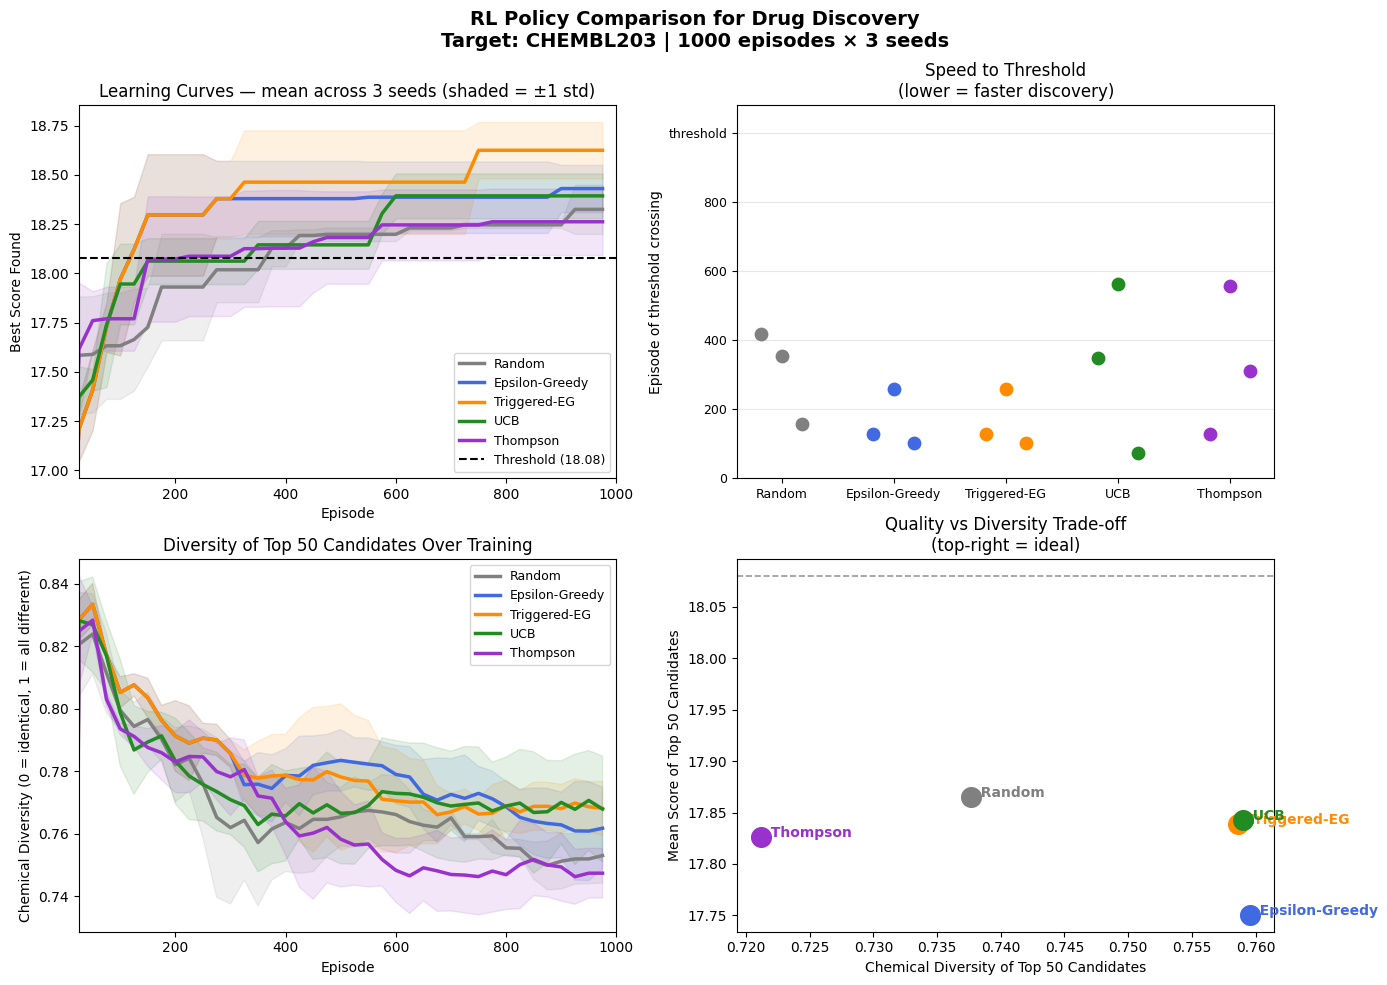

✓ Figure saved: rl_policy_comparison.png


In [ ]:
# ── Generate the 4-panel comparison figure ───────────────────
# Helper functions (aggregate, summary_stats) and the policy_names/
# policy_colors lists are defined earlier in the notebook.

# ── Generate the 4-panel figure ──────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    f'RL Policy Comparison for Drug Discovery\n'
    f'Target: {CONFIG["target_chembl_id"]} | '
    f'{CONFIG["episodes"]} episodes × {len(CONFIG["random_seeds"])} seeds',
    fontsize=14, fontweight='bold'
)

# ── Plot 1: Learning Curves ───────────────────────────────────
ax = axes[0, 0]
_y1_vals = []
for name, color in zip(policy_names, policy_colors):
    mean, std = aggregate(all_results[name], 'best_over_time')
    x = np.arange(len(mean)) * CONFIG['eval_interval']
    # Only consider values after episode 25 for y-axis range
    mask = x >= 25
    _y1_vals.extend((mean - std)[mask])
    _y1_vals.extend((mean + std)[mask])
    ax.plot(x, mean, color=color, linewidth=2.5, label=name)
    ax.fill_between(x, mean-std, mean+std, alpha=0.12, color=color)
ax.axhline(y=CONFIG['score_threshold'], color='black', linestyle='--',
           linewidth=1.5, label=f'Threshold ({CONFIG["score_threshold"]})')
ax.set_xlim(25, CONFIG['episodes'])
_y1_pad = (max(_y1_vals) - min(_y1_vals)) * 0.05
ax.set_ylim(min(_y1_vals) - _y1_pad, max(_y1_vals) + _y1_pad)
ax.set_xlabel('Episode')
ax.set_ylabel('Best Score Found')
ax.set_title(f'Learning Curves — mean across {len(CONFIG["random_seeds"])} seeds (shaded = ±1 std)')
ax.legend(fontsize=9)

# ── Plot 2: Speed to Threshold — scatter plot ────────────────
# Each seed is a dot at the episode it crossed threshold.
# Seeds that did not cross are shown as hollow circles at
# the top of the y-axis (episode budget), with y-axis labeled
# "threshold" to distinguish them from genuine crossings.
ax = axes[0, 1]
n_seeds  = len(CONFIG['random_seeds'])
jitter_offsets = np.linspace(-0.18, 0.18, n_seeds) if n_seeds > 1 else [0]
NO_CROSS = CONFIG['episodes']

for i, (name, color) in enumerate(zip(policy_names, policy_colors)):
    for si, r in enumerate(all_results[name]):
        ep = r['episodes_to_threshold'] if r['threshold_reached'] else NO_CROSS
        crossed = r['threshold_reached']
        xpos = i + jitter_offsets[si]
        if crossed:
            ax.scatter(xpos, ep, color=color, s=80, zorder=3)
        else:
            ax.scatter(xpos, ep, color='none', edgecolors=color,
                       linewidths=1.5, s=80, zorder=3)

ax.set_xticks(range(len(policy_names)))
ax.set_xticklabels(policy_names, fontsize=9)
ax.set_ylim(0, NO_CROSS * 1.08)
ax.set_yticks(list(range(0, NO_CROSS, 200)) + [NO_CROSS])
ax.set_yticklabels(
    [str(t) for t in range(0, NO_CROSS, 200)] + ['threshold'],
    fontsize=9
)
ax.set_ylabel(f'Episode of threshold crossing')
ax.set_title('Speed to Threshold\n(lower = faster discovery)')
ax.yaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)

# ── Plot 3: Diversity Over Time ───────────────────────────────
ax = axes[1, 0]
_y3_vals = []
for name, color in zip(policy_names, policy_colors):
    mean, std = aggregate(all_results[name], 'diversity_over_time')
    x = np.arange(len(mean)) * CONFIG['eval_interval']
    mask = x >= 25
    _y3_vals.extend((mean - std)[mask])
    _y3_vals.extend((mean + std)[mask])
    ax.plot(x, mean, color=color, linewidth=2.5, label=name)
    ax.fill_between(x, mean-std, mean+std, alpha=0.12, color=color)
ax.set_xlim(25, CONFIG['episodes'])
_y3_pad = (max(_y3_vals) - min(_y3_vals)) * 0.05
ax.set_ylim(min(_y3_vals) - _y3_pad, max(_y3_vals) + _y3_pad)
ax.set_xlabel('Episode')
ax.set_ylabel('Chemical Diversity (0 = identical, 1 = all different)')
ax.set_title('Diversity of Top 50 Candidates Over Training')
ax.legend(fontsize=9)

# ── Plot 4: Quality vs Diversity ──────────────────────────────
ax = axes[1, 1]
for name, color in zip(policy_names, policy_colors):
    s = summary_stats(all_results[name])
    ax.scatter(s['diversity'], s['mean_top50'], color=color, s=200, zorder=5)
    ax.annotate(f'  {name}', (s['diversity'], s['mean_top50']),
                fontsize=10, color=color, fontweight='bold')
ax.axhline(y=CONFIG['score_threshold'], color='black',
           linestyle='--', alpha=0.4, linewidth=1.2)
ax.set_xlabel('Chemical Diversity of Top 50 Candidates')
ax.set_ylabel('Mean Score of Top 50 Candidates')
ax.set_title('Quality vs Diversity Trade-off\n(top-right = ideal)')
ax.annotate('★ Ideal zone', xy=(0.6, CONFIG['score_threshold'] + 0.1),
            fontsize=10, color='darkgreen')

plt.tight_layout()
plt.savefig('rl_policy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Figure saved: rl_policy_comparison.png')

## 16. Per-Episode Best Score

The only non-cumulative curve in the notebook, and therefore the only one that can show learning or its absence.


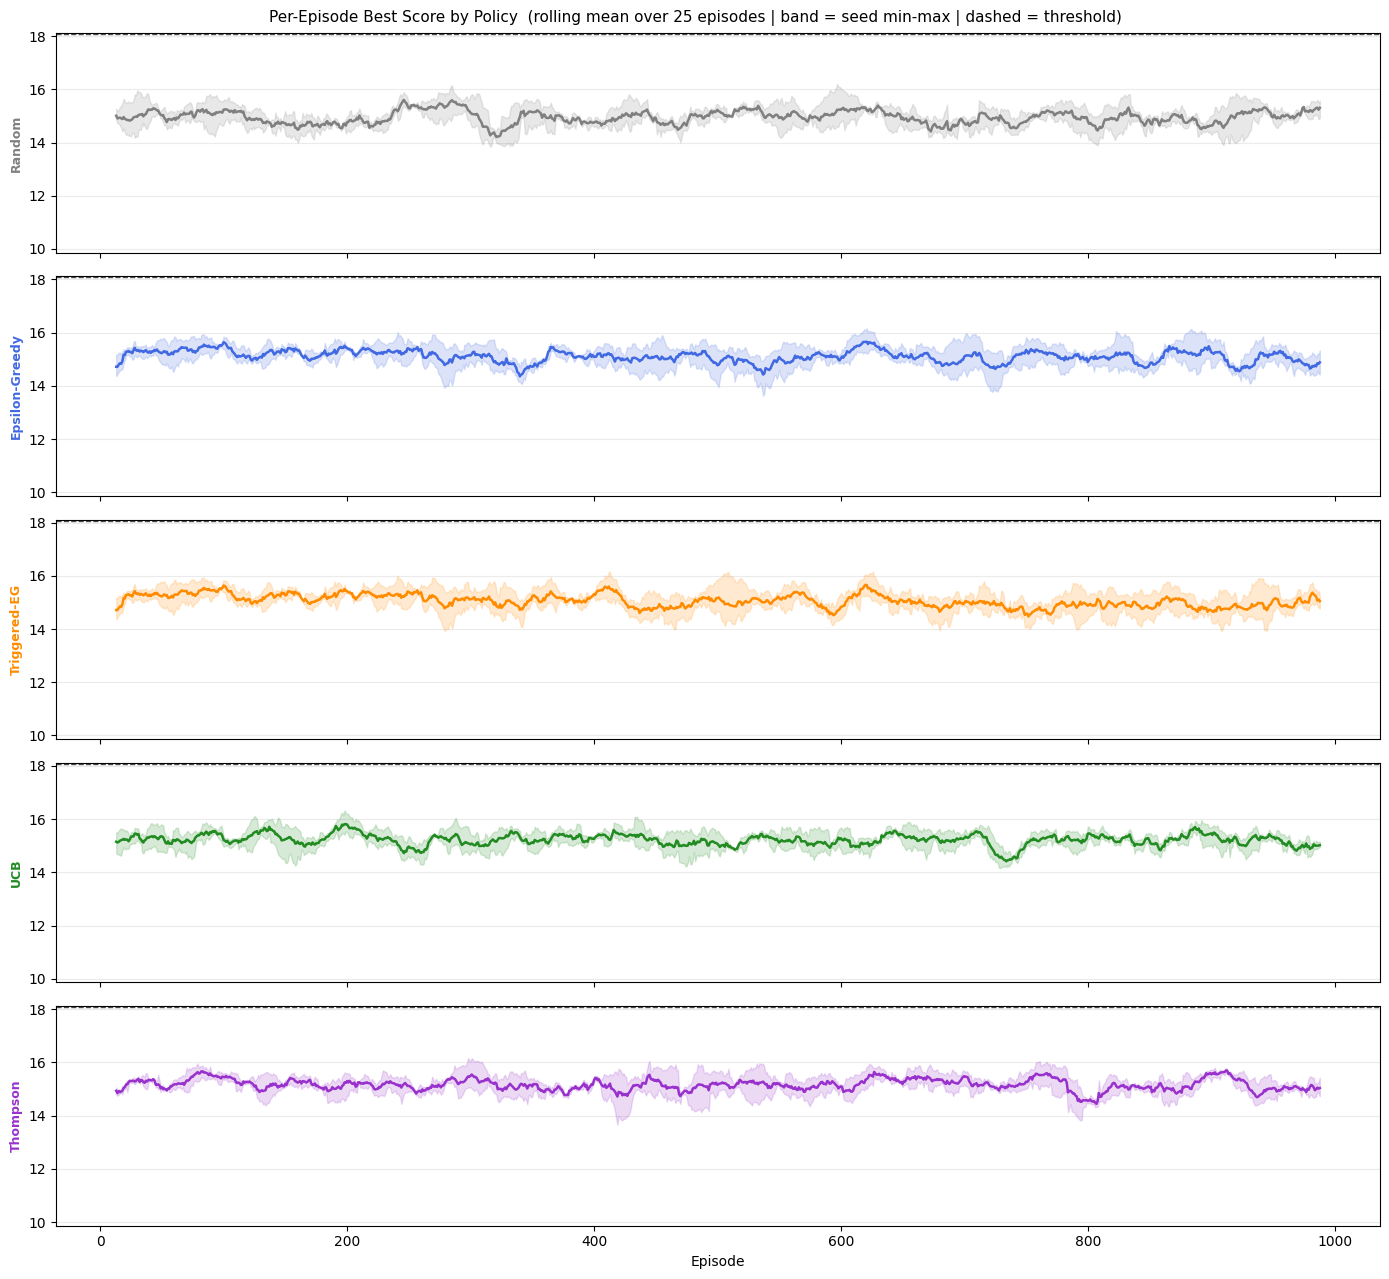

✓ Figure saved: rl_episode_scores.png


In [ ]:
# ── Per-episode best score — one row per policy, rolling mean ──
# This is the only non-cumulative curve in the notebook: unlike
# best_over_time (which is a running maximum and therefore monotonic by
# construction), this CAN go down, so it is the one plot able to show
# learning — or its absence.
#
# Raw per-episode scores are dominated by the reset lottery (which scaffold
# each episode happened to draw), so they are smoothed over SMOOTH episodes
# to average that noise out and leave the trend.

SMOOTH = 25  # rolling window, in episodes

def _rolling_mean(a, w):
    a = np.asarray(a, dtype=float)
    if w <= 1 or len(a) < w:
        return a, np.arange(1, len(a) + 1)
    sm = np.convolve(a, np.ones(w) / w, mode='valid')
    x  = np.arange(w // 2 + 1, w // 2 + 1 + len(sm))   # centre the window
    return sm, x

fig, axes = plt.subplots(len(POLICIES), 1,
                         figsize=(14, 2.6 * len(POLICIES)),
                         sharex=True, sharey=True)
fig.suptitle(f'Per-Episode Best Score by Policy  '
             f'(rolling mean over {SMOOTH} episodes | band = seed min-max | dashed = threshold)',
             fontsize=11)

# Shared y-limits from percentiles across ALL policies, so a handful of poor
# episodes cannot squash the region of interest, and all panels stay comparable.
pooled = np.concatenate([np.asarray(r['episode_scores'], dtype=float)
                         for name in policy_names
                         for r in all_results[name] if r.get('episode_scores')])
ylo, yhi = np.percentile(pooled, [2, 99.8])

for ax, name, color in zip(np.atleast_1d(axes), policy_names, policy_colors):
    curves = [r['episode_scores'] for r in all_results[name] if r.get('episode_scores')]
    if not curves:
        continue
    L  = min(len(c) for c in curves)
    smoothed = [_rolling_mean(c[:L], SMOOTH) for c in curves]
    sm = np.array([s for s, _ in smoothed])   # (n_seeds, n_points)
    x  = smoothed[0][1]                        # x positions, same for every seed

    # Seed spread as a band rather than N overlapping lines
    ax.fill_between(x, sm.min(axis=0), sm.max(axis=0), color=color, alpha=0.18)
    ax.plot(x, sm.mean(axis=0), color=color, linewidth=1.8)

    ax.axhline(CONFIG['score_threshold'], color='black', ls='--', lw=1.0, alpha=0.7)
    ax.set_ylabel(name, fontsize=9, color=color, fontweight='bold')
    ax.set_ylim(ylo, yhi)
    ax.yaxis.grid(True, alpha=0.25)
    ax.set_axisbelow(True)

np.atleast_1d(axes)[-1].set_xlabel('Episode', fontsize=10)
plt.tight_layout()
plt.savefig('rl_episode_scores.png', dpi=150, bbox_inches='tight')
plt.show()
print('\u2713 Figure saved: rl_episode_scores.png')


## 17. QSAR Virtual Screening Baseline


In [ ]:
def run_qsar_virtual_screening(df, qsar_model, top_n=50):
    """
    Traditional QSAR virtual screening:
    1. Score every compound in the held-out test library
    2. Rank by combined drug score
    3. Return the top_n candidates

    This mirrors real virtual screening campaigns where a QSAR model
    is used to triage a large compound library before synthesis.
    """
    print('Running QSAR virtual screening...')
    t0 = time.time()

    # Restrict to the same middle-50% pool used as RL seed molecules
    # (25th–75th pChEMBL percentile, threshold outliers removed).
    # Using the full library gives QSAR access to top-scoring compounds
    # that RL agents never start from — an unfair advantage.
    filter_cutoff = CONFIG.get('pool_filter_cutoff', CONFIG['score_threshold'])
    mid_smiles = [smi for smi in build_seed_slice(df)
                  if compute_drug_score(smi, qsar_model) < filter_cutoff]
    # Split held-out 20% from this restricted pool for fair evaluation
    _, test_smiles = train_test_split(mid_smiles, test_size=0.2, random_state=42)
    print(f'  Screening library: {len(test_smiles)} compounds (middle-50% pool, 20% held-out)')

    scored = []
    for smi in test_smiles:
        score = compute_drug_score(smi, qsar_model)
        if score > -10.0:   # filter out scoring failures
            scored.append((smi, score))

    # Rank highest to lowest
    scored.sort(key=lambda x: x[1], reverse=True)
    top_candidates = scored[:top_n]

    elapsed = time.time() - t0

    # Compute summary stats
    scores      = [s for _, s in top_candidates]
    smiles_list = [s for s, _ in top_candidates]

    results = {
        'candidates':      top_candidates,   # top 50 — for the top-50 comparison
        # Full scored library. The full-population comparison MUST use this, not
        # 'candidates': comparing an RL policy's entire molecule set against
        # QSAR's best 50 is a selected-vs-unselected mismatch that QSAR wins by
        # construction, regardless of either method's quality.
        'all_scored':      scored,
        'max_score':       max(scores),
        'mean_score':      np.mean(scores),
        'std_score':       np.std(scores),
        'above_threshold': sum(1 for s in scores if s >= CONFIG['score_threshold']),
        'diversity':       compute_diversity(smiles_list),
        'elapsed':         elapsed,
        'library_size':    len(test_smiles),
    }

    # Novelty: how similar are the top hits to the training data?
    # For QSAR screening this will be HIGH (library compounds are known)
    train_smiles, _ = train_test_split(
        df['canonical_smiles'].tolist(), test_size=0.2, random_state=42
    )
    sample_train = random.sample(train_smiles, min(100, len(train_smiles)))
    novelty_scores = []
    for smi in smiles_list[:20]:   # sample top 20 for speed
        sims = [tanimoto_similarity(smi, t) for t in sample_train]
        novelty_scores.append(1.0 - max(sims))   # novelty = 1 - max_similarity
    results['novelty'] = np.mean(novelty_scores)

    print(f'  Screened {len(scored)} compounds in {elapsed:.1f}s')
    print(f'  Top {top_n} candidates:')
    print(f'    Max score:       {results["max_score"]:.3f}')
    print(f'    Mean score:      {results["mean_score"]:.3f} ± {results["std_score"]:.3f}')
    print(f'    Above threshold: {results["above_threshold"]}/{top_n}')
    print(f'    Diversity:       {results["diversity"]:.3f}')
    print(f'    Novelty:         {results["novelty"]:.3f}  (QSAR finds known molecules — expected low)')
    return results


def tanimoto_similarity(smi1, smi2):
    """Tanimoto similarity between two SMILES — 0=different, 1=identical"""
    try:
        mol1 = Chem.MolFromSmiles(smi1)
        mol2 = Chem.MolFromSmiles(smi2)
        if mol1 is None or mol2 is None:
            return 0.0
        fp1 = AllChem.GetMorganFingerprintAsBitVect(mol1, 2, 1024)
        fp2 = AllChem.GetMorganFingerprintAsBitVect(mol2, 2, 1024)
        return DataStructs.TanimotoSimilarity(fp1, fp2)
    except Exception:
        return 0.0


qsar_screening_results = run_qsar_virtual_screening(df, qsar_model, top_n=50)
print('✓ QSAR virtual screening complete')

Running QSAR virtual screening...
  Screening library: 571 compounds (middle-50% pool, 20% held-out)
  Screened 571 compounds in 34.0s
  Top 50 candidates:
    Max score:       17.610
    Mean score:      17.244 ± 0.215
    Above threshold: 0/50
    Diversity:       0.750
    Novelty:         0.492  (QSAR finds known molecules — expected low)
✓ QSAR virtual screening complete


## 18. Head-to-Head: Top 50

RL policies versus QSAR screening on each method's best 50 molecules.


Computing novelty scores for all methods...
  Random             novelty = 0.645
  Epsilon-Greedy     novelty = 0.582
  Triggered-EG       novelty = 0.609
  UCB                novelty = 0.625
  Thompson           novelty = 0.583
  QSAR Screening     novelty = 0.492


Mann-Whitney U Test — RL Policies vs QSAR (one-sided: RL > QSAR)
  Policy            U-stat   win frac     p-value  Significant?
  ---------------------------------------------------------------
  Random              2497      0.999      0.0000  ✓ Yes (p<0.05)
  Epsilon-Greedy      2436      0.975      0.0000  ✓ Yes (p<0.05)
  Triggered-EG        2474      0.989      0.0000  ✓ Yes (p<0.05)
  UCB                 2472      0.989      0.0000  ✓ Yes (p<0.05)
  Thompson            2488      0.995      0.0000  ✓ Yes (p<0.05)

Mann-Whitney U Test — RL Policies vs Random (one-sided: RL > Random)
  Policy            U-stat   win frac     p-value  Significant?
  ---------------------------------------------------------------
  Epsil

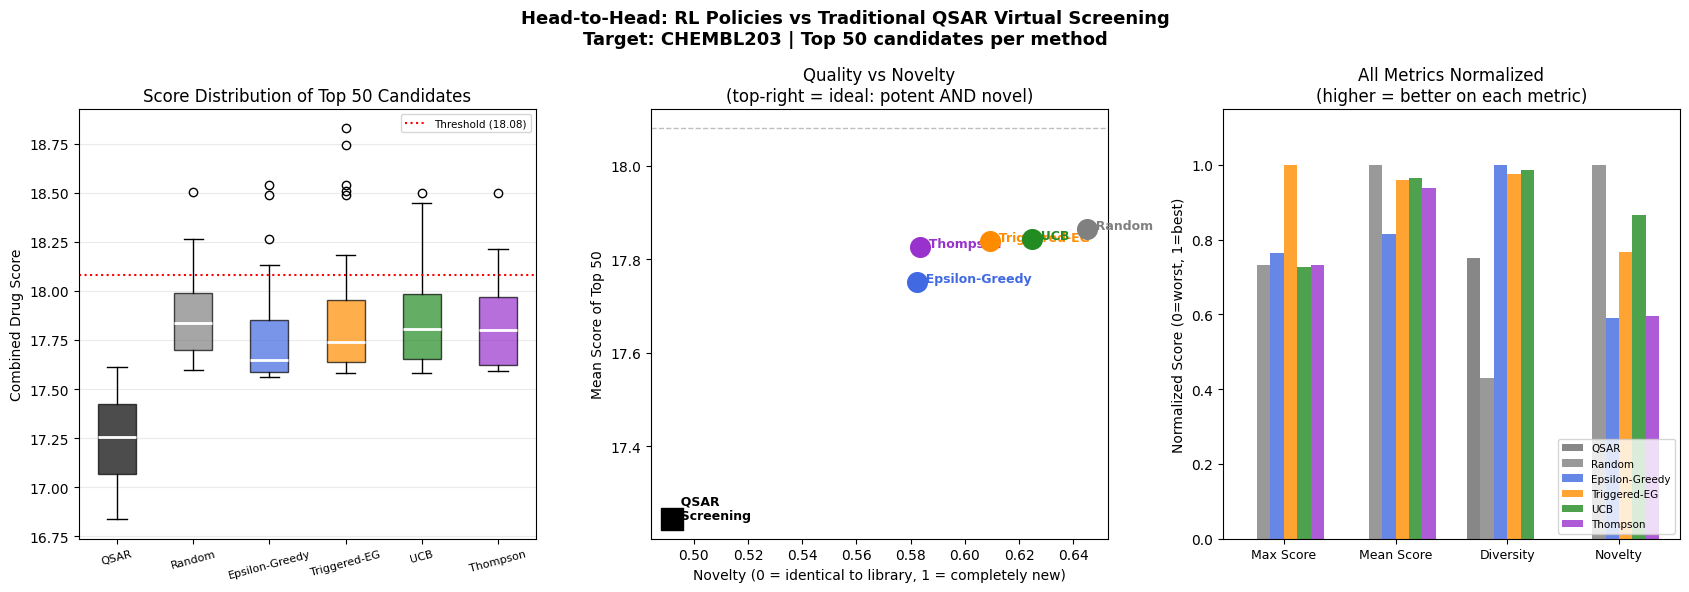

✓ Figure saved: rl_vs_qsar_headtohead.png

HEAD-TO-HEAD: RL POLICIES vs QSAR VIRTUAL SCREENING
Method                  Max   Mean   Above  Diversity  Novelty
                      Score  Score  Thresh                    
-─────────────────────────────────────────────────────────────────────────────────
QSAR Screening        17.61  17.24       0      0.750    0.492  ← traditional baseline
-─────────────────────────────────────────────────────────────────────────────────
Random                18.50  17.86↑       8      0.738     0.645↑
Epsilon-Greedy        18.54  17.75↑       5      0.760↑    0.582↑
Triggered-EG          18.83  17.84↑       7      0.759↑    0.609↑
UCB                   18.50  17.84↑       9      0.759↑    0.625↑
Thompson              18.50  17.83↑       9      0.721     0.583↑
↑ = beats QSAR screening on this metric


In [ ]:
# ── Compute novelty for each RL policy ────────────────────────
# Novelty = how different are discovered molecules from the training library?
# RL should score higher than QSAR here (it generates new molecules)

train_smiles, _ = train_test_split(
    df['canonical_smiles'].tolist(), test_size=0.2, random_state=42
)
sample_train = random.sample(train_smiles, min(100, len(train_smiles)))

def compute_novelty_vs_library(smiles_list, library_sample, n=20):
    """
    For each molecule, find its maximum similarity to any training compound.
    Novelty = 1 - max_similarity.
    Low novelty = molecule already exists in library (bad for drug discovery).
    High novelty = genuinely new chemical matter (good).
    """
    novelties = []
    for smi in smiles_list[:n]:
        sims = [tanimoto_similarity(smi, t) for t in library_sample]
        novelties.append(1.0 - max(sims) if sims else 0.0)
    return np.mean(novelties)

print('Computing novelty scores for all methods...')
rl_novelties = {}
for name in policy_names:
    top  = top_molecules(all_results[name], 20)
    smis = [s for s, _ in top]
    rl_novelties[name] = compute_novelty_vs_library(smis, sample_train)
    print(f'  {name:<18} novelty = {rl_novelties[name]:.3f}')

qsar_novelty = qsar_screening_results['novelty']
print(f'  {"QSAR Screening":<18} novelty = {qsar_novelty:.3f}')
print()

# ── Build the 3-panel head-to-head figure ────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 6))
fig.suptitle(
    'Head-to-Head: RL Policies vs Traditional QSAR Virtual Screening\n'
    f'Target: {CONFIG["target_chembl_id"]} | Top 50 candidates per method',
    fontsize=13, fontweight='bold'
)

# ── Panel 1: Score distributions — box plot ──────────────────

ax = axes[0]
qsar_scores = [s for _, s in qsar_screening_results['candidates']]

def get_top50_scores(name):
    all_scores = []
    for r in all_results[name]:
        scores = sorted([s for _, s in r['all_molecules']], reverse=True)[:50]
        all_scores.extend(scores)
    return sorted(all_scores, reverse=True)[:50]

box_labels = ['QSAR'] + list(policy_names)
box_data   = [qsar_scores] + [get_top50_scores(n) for n in policy_names]
box_colors = ['black'] + list(policy_colors)

bp = ax.boxplot(box_data, patch_artist=True, widths=0.5,
                medianprops=dict(color='white', linewidth=2))
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.axhline(CONFIG['score_threshold'], color='red', linestyle=':',
           linewidth=1.5, label=f'Threshold ({CONFIG["score_threshold"]})')
ax.set_xticks(range(1, len(box_labels) + 1))
ax.set_xticklabels(box_labels, fontsize=8, rotation=15)
ax.set_ylabel('Combined Drug Score')
ax.set_title('Score Distribution of Top 50 Candidates')
ax.legend(fontsize=7.5)
ax.yaxis.grid(True, alpha=0.25)
ax.set_axisbelow(True)

# ── Mann-Whitney U tests: each RL policy vs QSAR ─────────────
# "win frac" = U / (n*m): the fraction of all pairwise comparisons the policy
# wins. 0.5 is a tie. This is the effect size — raw U scales with sample sizes,
# so it says more about n than about the difference. Report both.
print('\nMann-Whitney U Test — RL Policies vs QSAR (one-sided: RL > QSAR)')
print(f'  {"Policy":<15} {"U-stat":>8}  {"win frac":>9}  {"p-value":>10}  {"Significant?":>12}')
print('  ' + '-' * 63)
for name, scores in zip(policy_names, box_data[1:]):
    u_stat, p_val = _scipy_stats.mannwhitneyu(scores, qsar_scores,
                                               alternative='greater')
    frac = u_stat / (len(scores) * len(qsar_scores))
    sig = '✓ Yes (p<0.05)' if p_val < 0.05 else '✗ No'
    print(f'  {name:<15} {u_stat:>8.0f}  {frac:>9.3f}  {p_val:>10.4f}  {sig:>12}')

# ── Mann-Whitney U tests: each RL policy vs Random ────────────
random_scores = get_top50_scores('Random')
print('\nMann-Whitney U Test — RL Policies vs Random (one-sided: RL > Random)')
print(f'  {"Policy":<15} {"U-stat":>8}  {"win frac":>9}  {"p-value":>10}  {"Significant?":>12}')
print('  ' + '-' * 63)
for name, scores in zip(policy_names, box_data[1:]):
    if name == 'Random':
        continue
    u_stat, p_val = _scipy_stats.mannwhitneyu(scores, random_scores,
                                               alternative='greater')
    frac = u_stat / (len(scores) * len(random_scores))
    sig = '✓ Yes (p<0.05)' if p_val < 0.05 else '✗ No'
    print(f'  {name:<15} {u_stat:>8.0f}  {frac:>9.3f}  {p_val:>10.4f}  {sig:>12}')

# ── Panel 2: Quality vs Novelty scatter ──────────────────────
ax = axes[1]

# Plot QSAR point
ax.scatter(qsar_novelty, qsar_screening_results['mean_score'],
           color='black', s=250, marker='s', zorder=5,
           label='QSAR Screening')
ax.annotate('  QSAR\n  Screening',
            (qsar_novelty, qsar_screening_results['mean_score']),
            fontsize=9, color='black', fontweight='bold')

# Plot each RL policy
for name, color in zip(policy_names, policy_colors):
    s = summary_stats(all_results[name])
    ax.scatter(rl_novelties[name], s['mean_top50'],
               color=color, s=200, zorder=5)
    ax.annotate(f'  {name}',
                (rl_novelties[name], s['mean_top50']),
                fontsize=9, color=color, fontweight='bold')

# Ideal zone annotation
ax.axhline(CONFIG['score_threshold'], color='gray',
           linestyle='--', alpha=0.5, linewidth=1)
ax.set_xlabel('Novelty (0 = identical to library, 1 = completely new)')
ax.set_ylabel('Mean Score of Top 50')
ax.set_title('Quality vs Novelty\n(top-right = ideal: potent AND novel)')
ax.annotate('★ Ideal\n   zone', xy=(0.65, CONFIG['score_threshold'] + 0.05),
            fontsize=9, color='darkgreen',
            bbox=dict(boxstyle='round', facecolor='honeydew', alpha=0.7))

# ── Panel 3: Summary bar chart ───────────────────────────────
ax = axes[2]

all_names  = ['QSAR'] + policy_names
all_colors = ['dimgray'] + policy_colors

# Collect metrics
max_scores  = [qsar_screening_results['max_score']]  + \
              [summary_stats(all_results[n])['max_score']  for n in policy_names]
mean_scores = [qsar_screening_results['mean_score']] + \
              [summary_stats(all_results[n])['mean_top50'] for n in policy_names]
diversities = [qsar_screening_results['diversity']]  + \
              [summary_stats(all_results[n])['diversity']  for n in policy_names]
novelties   = [qsar_novelty] + [rl_novelties[n] for n in policy_names]

# Normalize all metrics 0-1 for radar-style bar
def normalize(vals):
    mn, mx = min(vals), max(vals)
    if mx == mn:
        return [0.5] * len(vals)
    return [(v - mn) / (mx - mn) for v in vals]

metrics = {
    'Max Score':   normalize(max_scores),
    'Mean Score':  normalize(mean_scores),
    'Diversity':   normalize(diversities),
    'Novelty':     normalize(novelties),
}

x      = np.arange(len(metrics))
width  = 0.12
n_methods = len(all_names)
offsets   = np.linspace(-(n_methods-1)/2, (n_methods-1)/2, n_methods) * width

for i, (name, color) in enumerate(zip(all_names, all_colors)):
    vals = [metrics[m][i] for m in metrics]
    bars = ax.bar(x + offsets[i], vals, width,
                  color=color, alpha=0.8, label=name)

ax.set_xticks(x)
ax.set_xticklabels(list(metrics.keys()), fontsize=9)
ax.set_ylabel('Normalized Score (0=worst, 1=best)')
ax.set_title('All Metrics Normalized\n(higher = better on each metric)')
ax.legend(fontsize=7.5, loc='lower right')
ax.set_ylim(0, 1.15)

plt.tight_layout()
plt.savefig('rl_vs_qsar_headtohead.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Figure saved: rl_vs_qsar_headtohead.png')

# ── Print head-to-head summary table ──────────────────────────
print()
print(f'={"="*82}')
print('HEAD-TO-HEAD: RL POLICIES vs QSAR VIRTUAL SCREENING')
print(f'={"="*82}')
print(f'{"Method":<20} {"Max":>6} {"Mean":>6} {"Above":>7} {"Diversity":>10} {"Novelty":>8}')
print(f'{"":<20} {"Score":>6} {"Score":>6} {"Thresh":>7} {"":>10} {"":>8}')
print(f'-{"─"*81}')

# QSAR row
q = qsar_screening_results
print(f'{"QSAR Screening":<20} {q["max_score"]:>6.2f} {q["mean_score"]:>6.2f} '
      f'{q["above_threshold"]:>7} {q["diversity"]:>10.3f} {q["novelty"]:>8.3f}  ← traditional baseline')
print(f'-{"─"*81}')

# RL policy rows
for name in policy_names:
    s   = summary_stats(all_results[name])
    nov = rl_novelties[name]
    # Highlight if RL beats QSAR
    score_flag = '↑' if s['mean_top50'] > q['mean_score'] else ' '
    nov_flag   = '↑' if nov            > q['novelty']     else ' '
    div_flag   = '↑' if s['diversity'] > q['diversity']   else ' '
    print(
        f'{name:<20} {s["max_score"]:>6.2f} '
        f'{s["mean_top50"]:>6.2f}{score_flag} '
        f'{s["above_threshold"]:>7} '
        f'{s["diversity"]:>10.3f}{div_flag} '
        f'{nov:>8.3f}{nov_flag}'
    )

print(f'={"="*82}')
print('↑ = beats QSAR screening on this metric')

## 19. Head-to-Head: Full Population

The same comparison across every molecule generated, not just the top 50. This is the comparison that stays invariant across hardware, episode budget and seed count.


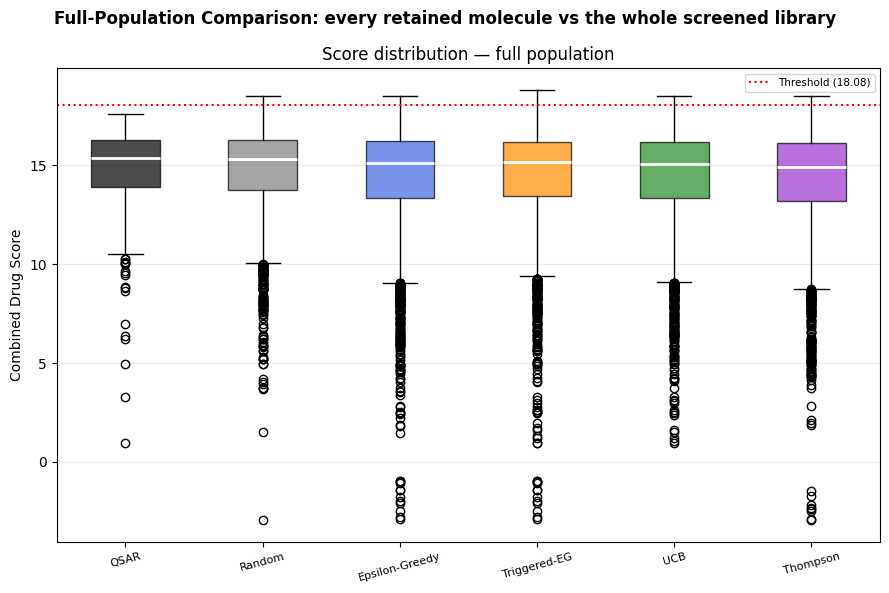


Mann-Whitney U — full population, policies vs QSAR (one-sided: policy > QSAR)
  Policy            U-stat   win frac     p-value  Significant?
  ---------------------------------------------------------------
  Random              969152     0.495     0.6579            no
  Epsilon-Greedy     1028804     0.462     0.9981            no
  Triggered-EG       1019741     0.469     0.9921            no
  UCB                1054693     0.455     0.9998            no
  Thompson           1079566     0.445     1.0000            no

Mann-Whitney U — full population, policies vs Random (one-sided: policy > Random)
  Policy              U-stat  win frac    p-value  Significant?
  ---------------------------------------------------------------
  Epsilon-Greedy     6253727     0.468     1.0000            no
  Triggered-EG       6200302     0.474     0.9999            no
  UCB                6420059     0.461     1.0000            no
  Thompson           6574200     0.451     1.0000            no

F

In [ ]:
# ── FULL-POPULATION comparison ────────────────────────────────
# Every trajectory-best molecule each policy retained, vs the ENTIRE
# scored QSAR library. Both sides unselected — the top-50 comparison
# lives in the previous cell.
#
# Diversity and novelty are deliberately NOT reported here: both are
# defined over a small top-N sample and have no meaningful full-set
# analogue at this cost. See the top-50 cell for those.

def get_all_scores(name):
    """Every score in all_molecules across seeds — NOT truncated."""
    scores = []
    for r in all_results[name]:
        scores.extend(s for _, s in r['all_molecules'])
    return sorted(scores, reverse=True)

qsar_scores = [s for _, s in qsar_screening_results['all_scored']]
box_labels  = ['QSAR'] + list(policy_names)
box_data    = [qsar_scores] + [get_all_scores(n) for n in policy_names]
box_colors  = ['black'] + list(policy_colors)

# ── Panel: full-set score distributions ──────────────────────
fig, ax = plt.subplots(figsize=(9, 6))
fig.suptitle('Full-Population Comparison: every retained molecule vs the whole screened library',
             fontsize=12, fontweight='bold')

bp = ax.boxplot(box_data, patch_artist=True, widths=0.5,
                medianprops=dict(color='white', linewidth=2))
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color); patch.set_alpha(0.7)

ax.axhline(CONFIG['score_threshold'], color='red', linestyle=':', linewidth=1.5,
           label=f'Threshold ({CONFIG["score_threshold"]})')
ax.set_xticks(range(1, len(box_labels) + 1))
ax.set_xticklabels(box_labels, fontsize=8, rotation=15)
ax.set_ylabel('Combined Drug Score')
ax.set_title('Score distribution — full population')
ax.legend(fontsize=7.5); ax.yaxis.grid(True, alpha=0.25); ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('rl_vs_qsar_fullpop.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Mann-Whitney: each policy vs QSAR ────────────────────────
print('\nMann-Whitney U — full population, policies vs QSAR (one-sided: policy > QSAR)')
print(f'  {"Policy":<15} {"U-stat":>8}  {"win frac":>9}  {"p-value":>10}  {"Significant?":>12}')
print('  ' + '-' * 63)
for name, scores in zip(policy_names, box_data[1:]):
    u, p = _scipy_stats.mannwhitneyu(scores, qsar_scores, alternative='greater')
    frac = u / (len(scores) * len(qsar_scores))
    print(f'  {name:<15} {u:>10.0f} {frac:>9.3f} {p:>10.4f}  {"YES (p<0.05)" if p < 0.05 else "no":>12}')

# ── Mann-Whitney: each policy vs Random ──────────────────────
random_scores = get_all_scores('Random')
print('\nMann-Whitney U — full population, policies vs Random (one-sided: policy > Random)')
print(f'  {"Policy":<15} {"U-stat":>8} {"win frac":>9} {"p-value":>10}  {"Significant?":>12}')
print('  ' + '-' * 63)
for name, scores in zip(policy_names, box_data[1:]):
    if name == 'Random':
        continue
    u, p = _scipy_stats.mannwhitneyu(scores, random_scores, alternative='greater')
    frac = u / (len(scores) * len(random_scores))
    print(f'  {name:<15} {u:>10.0f} {frac:>9.3} {p:>10.4f}  {"YES (p<0.05)" if p < 0.05 else "no":>12}')

# ── Full-population summary table ────────────────────────────
print()
print('=' * 62)
print('FULL POPULATION — every retained molecule vs the whole library')
print('=' * 62)
print(f'{"Method":<20} {"n":>7} {"Max":>7} {"Mean":>7} {"Median":>7}')
print('-' * 62)
for label, scores in zip(box_labels, box_data):
    print(f'{label:<20} {len(scores):>7} {max(scores):>7.2f} '
          f'{np.mean(scores):>7.2f} {np.median(scores):>7.2f}')
print('=' * 62)
print('Note: these populations are not independent samples — molecules within a')
print('policy share seeds, scaffolds and trajectories. Read as distributional')
print('comparison, not as a significance claim.')

# Part 6 — Diagnostics

*Investigations that support specific claims in the write-up. None of these feed the pipeline.*


## 20. Score Attractor Investigation


In [ ]:
# seed_scores used to be a by-product of a diagnostic cell that has since
# been removed. It is rebuilt here from the same pool the experiment uses,
# so this cell no longer depends on an unrelated diagnostic having run.
seed_scores = build_seed_scores(df, qsar_model)

# ── Collect all molecules at attractor score values ──────────
#
# Strategy: find score values that appear as best_score for multiple
# policy×seed combinations, then collect the actual SMILES to verify
# whether they represent the same molecule or score collisions.

from collections import defaultdict

# Gather (policy, seed, best_smi, best_score) for all runs
all_bests = []
for name in [P.name for P in POLICIES]:
    for i, r in enumerate(all_results[name]):
        seed = CONFIG['random_seeds'][i]
        if not r['all_molecules']:
            continue
        best_smi, best_score = max(r['all_molecules'], key=lambda x: x[1])
        all_bests.append((name, seed, best_smi, best_score))

# Group by rounded score to find attractors
score_groups = defaultdict(list)
for name, seed, smi, score in all_bests:
    score_groups[round(score, 3)].append((name, seed, smi))

# Filter to scores appearing in 2+ runs
attractors = {s: entries for s, entries in score_groups.items()
              if len(entries) >= 2}
attractors = dict(sorted(attractors.items(), reverse=True))

print('Score Attractor Investigation')
print('=' * 60)
print(f'Attractor score values (appearing as best in 2+ policy×seed runs):')
print()

for score, entries in attractors.items():
    print(f'Score {score:.3f} — {len(entries)} occurrences:')

    # Collect unique SMILES at this score
    unique_smiles = list({smi for _, _, smi in entries})

    for name, seed, smi in entries:
        print(f'  {name:<18} seed={seed:4d}  {smi[:60]}{"..." if len(smi)>60 else ""}')

    print(f'  Unique SMILES at this score: {len(unique_smiles)}')

    if len(unique_smiles) == 1:
        print(f'  → All runs converged to the SAME molecule')
        mol = Chem.MolFromSmiles(unique_smiles[0])
        if mol:
            ha  = mol.GetNumHeavyAtoms()
            mw  = Descriptors.MolWt(mol)
            qed = QED.qed(mol)
            lip = check_lipinski(mol)
            print(f'     Heavy atoms: {ha} | MW: {mw:.1f} | QED: {qed:.3f} | Lipinski: {"pass" if lip else "fail"}')
            # Check if it's in the seed pool
            if unique_smiles[0] in seed_scores:
                print(f'     → Direct seed molecule (score={seed_scores[unique_smiles[0]]:.3f})')
            else:
                # Find nearest seed
                fp = AllChem.GetMorganFingerprintAsBitVect(mol, 2, 1024)
                best_sim, best_seed_smi, best_seed_score = 0.0, None, 0.0
                for s_smi, s_score in seed_scores.items():
                    s_mol = Chem.MolFromSmiles(s_smi)
                    if s_mol is None:
                        continue
                    s_fp = AllChem.GetMorganFingerprintAsBitVect(s_mol, 2, 1024)
                    sim = DataStructs.TanimotoSimilarity(fp, s_fp)
                    if sim > best_sim:
                        best_sim, best_seed_smi, best_seed_score = sim, s_smi, s_score
                print(f'     → Derivative: nearest seed score={best_seed_score:.3f}, '
                      f'Tanimoto={best_sim:.3f}')
                print(f'        Score gain over nearest seed: {score - best_seed_score:+.3f}')
                print(f'        Nearest seed: {best_seed_smi[:60]}')
    else:
        # Check if any single SMILES appears 2+ times (partial attractor within collision)
        from collections import Counter
        smi_counts = Counter(smi for _, _, smi in entries)
        partial_attractors = {smi: cnt for smi, cnt in smi_counts.items() if cnt >= 2}

        if partial_attractors:
            print(f'  → MIXED: true attractor(s) + score collision')
            for smi, cnt in partial_attractors.items():
                mol = Chem.MolFromSmiles(smi)
                ha  = mol.GetNumHeavyAtoms() if mol else '?'
                policies = [(n, s) for n, s, sm in entries if sm == smi]
                print(f'  → TRUE ATTRACTOR ({cnt} runs converged):')
                print(f'     ha={ha}  {smi[:65]}{"..." if len(smi)>65 else ""}')
                for n, s in policies:
                    print(f'     ↳ {n:<18} seed={s}')
            collision_smiles = [smi for smi in unique_smiles if smi not in partial_attractors]
            if collision_smiles:
                print(f'  → COLLISION molecules (different SMILES, same score):')
                for smi in collision_smiles:
                    mol = Chem.MolFromSmiles(smi)
                    ha  = mol.GetNumHeavyAtoms() if mol else '?'
                    print(f'     ha={ha}  {smi[:65]}{"..." if len(smi)>65 else ""}')
        else:
            print(f'  → Score COLLISION — different molecules with same rounded score:')
            for smi in unique_smiles:
                mol = Chem.MolFromSmiles(smi)
                ha  = mol.GetNumHeavyAtoms() if mol else '?'
                print(f'     ha={ha}  {smi[:65]}{"..." if len(smi)>65 else ""}')
    print()

# ── Summary ───────────────────────────────────────────────────
print('=' * 60)
print('Summary:')
print(f'  Total policy×seed runs:   {len(all_bests)}')
print(f'  Distinct best scores:     {len(score_groups)}')
print(f'  Attractor scores (2+ runs): {len(attractors)}')
print()
# Separate true attractors (single SMILES) from score collisions (multiple SMILES)
true_attractors      = {s: e for s, e in attractors.items()
                        if len({smi for _, _, smi in e}) == 1}
score_collisions     = {s: e for s, e in attractors.items()
                        if len({smi for _, _, smi in e}) > 1}

if true_attractors:
    top_attractor_score = max(true_attractors.keys())
    top_entries = true_attractors[top_attractor_score]
    print(f'  Strongest TRUE attractor: {top_attractor_score:.3f} '
          f'({len(top_entries)} runs, same molecule)')
else:
    print('  No true attractors found — all multi-run scores are collisions.')

if score_collisions:
    print(f'  Score collisions: {len(score_collisions)} score value(s) where different '
          f'molecules achieved the same rounded score')
    print(f'  (Collisions indicate diversity, not convergence — not a concern)')
print()
print('Interpretation:')
print('  True attractor   → single unique SMILES, policies converged to same molecule')
print('  Score collision  → multiple different SMILES at same score — diversity, not trapping')
print('  In seed pool     → policies never escaped the starting compounds')
print('  Derivative       → policies made progress but got stuck at same point')


Score Attractor Investigation
Attractor score values (appearing as best in 2+ policy×seed runs):

Score 18.540 — 2 occurrences:
  Epsilon-Greedy     seed=  42  Cc1nc(F)ccc1[C@H](Nc1cc(Cl)c2ncc(C#N)c(NCC(C)(C)C)c2c1)C1=C2...
  Triggered-EG       seed=  42  Cc1nc(F)ccc1[C@H](Nc1cc(Cl)c2ncc(C#N)c(NCC(C)(C)C)c2c1)C1=C2...
  Unique SMILES at this score: 1
  → All runs converged to the SAME molecule
     Heavy atoms: 39 | MW: 550.1 | QED: 0.274 | Lipinski: pass
     → Derivative: nearest seed score=15.851, Tanimoto=0.802
        Score gain over nearest seed: +2.689
        Nearest seed: Cc1nc(F)ccc1[C@H](Nc1cc(Cl)c2ncc(C#N)c(NCC(C)(C)C)c2c1)C1=C2

Summary:
  Total policy×seed runs:   15
  Distinct best scores:     14
  Attractor scores (2+ runs): 1

  Strongest TRUE attractor: 18.540 (2 runs, same molecule)

Interpretation:
  True attractor   → single unique SMILES, policies converged to same molecule
  Score collision  → multiple different SMILES at same score — diversity, not trapping
  In

## 21. Triggered-EG Reset Diagnostics

Shows exactly when each stagnation reset fired — the evidence behind the finding that the trigger mechanism costs Triggered-EG its late payoffs.


In [ ]:
# ── Triggered Epsilon-Greedy reset diagnostic ────────────────
print('Triggered Epsilon-Greedy Reset Diagnostics')
print('=' * 55)
print(f'  Patience:    {CONFIG["trigger_patience"]} episodes')
print(f'  Reset to:    epsilon={CONFIG["trigger_epsilon_reset"]}')
print(f'  Max resets:  {CONFIG["trigger_max_resets"]}')
print(f'  Min delta:   {CONFIG["trigger_min_delta"]}')
print()

for name in [P.name for P in POLICIES]:
    results_list = all_results[name]
    has_resets = any(r.get('trigger_n_resets', 0) > 0 for r in results_list)
    if not has_resets and name != 'Triggered-EG':
        continue  # skip non-trigger policies with no resets

    print(f'{name}:')
    for i, r in enumerate(results_list):
        seed = CONFIG['random_seeds'][i]
        n    = r.get('trigger_n_resets', 0)
        log  = r.get('trigger_resets', [])
        if n == 0:
            print(f'  seed={seed:4d} → no resets fired')
        else:
            for reset_num, (ep, score) in enumerate(log, 1):
                print(f'  seed={seed:4d} → reset {reset_num}/{n} at ep {ep:4d} | score at reset: {score:.3f}')
    print()

# ── Score trajectory around resets ───────────────────────────
# For each reset, show best score before and after (using best_over_time snapshots).
# 'before' = best score at the reset episode snapshot
# 'after'  = best score approximately trigger_patience episodes later
# The delta reflects improvement within the post-reset exploration window.
# Note: delta=0 means no improvement was found in that window, not that
# the policy stopped exploring.
print('Score improvement after resets:')
print(f'  (delta measured over ~{CONFIG["trigger_patience"]} episodes following each reset)')
print('-' * 55)
teg_results = all_results.get('Triggered-EG', [])
for i, r in enumerate(teg_results):
    seed = CONFIG['random_seeds'][i]
    log  = r.get('trigger_resets', [])
    best_trajectory = r['best_over_time']
    interval = CONFIG['eval_interval']
    if not log:
        print(f'  seed={seed:4d} → no resets, final best: {max((s for _,s in r["all_molecules"]), default=0):.3f}')
        continue
    for ep, score_at_reset in log:
        # Find snapshot just before and after reset
        snap_before = ep // interval
        snap_after  = min(snap_before + int(CONFIG['trigger_patience'] // interval),
                         len(best_trajectory) - 1)
        score_before = best_trajectory[snap_before] if snap_before < len(best_trajectory) else score_at_reset
        score_after  = best_trajectory[snap_after]  if snap_after  < len(best_trajectory) else score_at_reset
        delta = score_after - score_before
        print(f'  seed={seed:4d} | reset@ep{ep} | before={score_before:.3f} → after={score_after:.3f} | Δ={delta:+.3f}')


Triggered Epsilon-Greedy Reset Diagnostics
  Patience:    200 episodes
  Reset to:    epsilon=1.0
  Max resets:  5
  Min delta:   0.0

Triggered-EG:
  seed=  42 → reset 1/4 at ep  327 | score at reset: 18.540
  seed=  42 → reset 2/4 at ep  527 | score at reset: 18.540
  seed=  42 → reset 3/4 at ep  727 | score at reset: 18.540
  seed=  42 → reset 4/4 at ep  927 | score at reset: 18.540
  seed= 123 → reset 1/3 at ep  458 | score at reset: 18.110
  seed= 123 → reset 2/3 at ep  658 | score at reset: 18.110
  seed= 123 → reset 3/3 at ep  935 | score at reset: 18.509
  seed= 456 → reset 1/4 at ep  300 | score at reset: 18.489
  seed= 456 → reset 2/4 at ep  515 | score at reset: 18.740
  seed= 456 → reset 3/4 at ep  715 | score at reset: 18.740
  seed= 456 → reset 4/4 at ep  948 | score at reset: 18.827

Score improvement after resets:
  (delta measured over ~200 episodes following each reset)
-------------------------------------------------------
  seed=  42 | reset@ep327 | before=18.540 →

## 22. Best Molecule Deep Dive


In [ ]:
# seed_scores used to be a by-product of a diagnostic cell that has since
# been removed. It is rebuilt here from the same pool the experiment uses,
# so this cell no longer depends on an unrelated diagnostic having run.
seed_scores = build_seed_scores(df, qsar_model)

# ── Configuration: which molecules to analyse ────────────────
# Specify (policy_name, seed_index) pairs to deep-dive.
# seed_index is the position in CONFIG['random_seeds'], not the seed value.
# Set to None to auto-select: top-3 by pChEMBL across all policy×seed runs.
DEEP_DIVE_TARGETS = None  # e.g. [('Epsilon-Greedy', 1), ('Triggered-EG', 0)]

# ── Action space labels (must match MoleculeEnv._apply_modification order) ──
ACTION_LABELS = ['Add F', 'Add Cl', 'Add CH₃', 'Add OH', 'Add NH₂', 'Add SH']

# ── Helper: full compound score breakdown ────────────────────
def score_breakdown(smiles, qsar_model):
    """Return dict with all score components for a SMILES string."""
    fp  = smiles_to_fp(smiles)
    mol = Chem.MolFromSmiles(smiles)
    if fp is None or mol is None:
        return None
    activity  = float(qsar_model.predict([fp])[0])
    qed_score = float(QED.qed(mol))
    lip_score = float(check_lipinski(mol))
    logp      = float(Crippen.MolLogP(mol))
    mw        = float(Descriptors.MolWt(mol))
    tox       = max(0, (logp - 5) * 0.5) + max(0, (mw - 500) * 0.005)
    w = CONFIG['reward_weights']
    composite = (w['activity']  * activity  +
                 w['qed']       * qed_score +
                 w['lipinski']  * lip_score +
                 w['toxicity']  * tox)
    # Lipinski detail
    lip_violations = {
        'MW > 500':   Descriptors.MolWt(mol) > 500,
        'LogP > 5':   logp > 5,
        'HBD > 5':    rdMolDescriptors.CalcNumHBD(mol) > 5,
        'HBA > 10':   rdMolDescriptors.CalcNumHBA(mol) > 10,
    }
    n_violations = sum(lip_violations.values())
    return {
        'smiles':        smiles,
        'pchembl':       activity,
        'qed':           qed_score,
        'lipinski':      lip_score,
        'lip_violations': lip_violations,
        'n_violations':  n_violations,
        'logp':          logp,
        'mw':            mw,
        'ha':            mol.GetNumHeavyAtoms(),
        'tox_raw':       tox,
        'tox_weighted':  w['toxicity'] * tox,
        'composite':     composite,
        'terms': {
            'activity':  w['activity'] * activity,
            'qed':       w['qed']      * qed_score,
            'lipinski':  w['lipinski'] * lip_score,
            'toxicity':  w['toxicity'] * tox,
        }
    }

# ── Helper: find nearest seed parent ─────────────────────────
def find_nearest_seed(smiles, seed_scores):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None, 0.0, 0.0
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, 2, 1024)
    best_sim, best_smi, best_score = 0.0, None, 0.0
    for s_smi, s_score in seed_scores.items():
        s_mol = Chem.MolFromSmiles(s_smi)
        if s_mol is None:
            continue
        s_fp = AllChem.GetMorganFingerprintAsBitVect(s_mol, 2, 1024)
        sim  = DataStructs.TanimotoSimilarity(fp, s_fp)
        if sim > best_sim:
            best_sim, best_smi, best_score = sim, s_smi, s_score
    return best_smi, best_sim, best_score

# ── Helper: W action analysis ─────────────────────────────────
def w_action_analysis(smiles, W):
    """Return Q-values for each action given molecule state and W snapshot."""
    state   = smiles_to_state(smiles)
    q_vals  = state @ W   # (n_actions,)
    ranked  = sorted(zip(ACTION_LABELS, q_vals), key=lambda x: x[1], reverse=True)
    return ranked

# ── Auto-select top-3 threshold crossers by composite score ──
# Only considers policy×seed runs that crossed the threshold.
# Ranked by composite score descending, pChEMBL as tiebreaker.
# If no threshold crossers exist, prints a message and skips analysis.
if DEEP_DIVE_TARGETS is None:
    candidates = []
    for name in [P.name for P in POLICIES]:
        for i, r in enumerate(all_results[name]):
            if not r['threshold_reached']:
                continue
            best_smi = r['best_w_smiles'] or max(r['all_molecules'], key=lambda x: x[1])[0]
            best_score = max(s for _, s in r['all_molecules'])
            fp = smiles_to_fp(best_smi)
            if fp is not None:
                pchembl = float(qsar_model.predict([fp])[0])
                candidates.append((best_score, pchembl, name, i, best_smi))
    if not candidates:
        print('No threshold crossers in this run — skipping deep dive analysis.')
        print('Re-run with a lower threshold or more episodes to generate threshold crossers.')
    else:
        candidates.sort(reverse=True)  # by composite score, then pChEMBL
        # Deduplicate by SMILES — keep highest-scoring entry for each unique molecule
        seen_smi = set()
        unique_candidates = []
        for c in candidates:
            smi = c[4]
            if smi not in seen_smi:
                seen_smi.add(smi)
                unique_candidates.append(c)
        DEEP_DIVE_TARGETS = [(name, i) for _, _, name, i, _ in unique_candidates[:3]]
        print(f"Auto-selected top-3 unique threshold crossers by composite score:")
        for score, pch, name, i, smi in unique_candidates[:3]:
            seed = CONFIG['random_seeds'][i]
            print(f"  {name} seed={seed}: score={score:.3f} pChEMBL={pch:.2f}  {smi[:55]}")
        print()

# ── Run analysis for each target ─────────────────────────────
if not DEEP_DIVE_TARGETS:
    DEEP_DIVE_TARGETS = []  # ensure iterable even if no crossers
for policy_name, seed_idx in DEEP_DIVE_TARGETS:
    r    = all_results[policy_name][seed_idx]
    seed = CONFIG['random_seeds'][seed_idx]
    smi  = r['best_w_smiles'] or max(r['all_molecules'], key=lambda x: x[1])[0]
    W    = r['best_w_snapshot']

    print('=' * 65)
    print(f'Policy: {policy_name}  |  seed={seed}')
    print('=' * 65)
    print(f'SMILES: {smi}')
    print()

    # ── Compound score breakdown ──────────────────────────────
    bd = score_breakdown(smi, qsar_model)
    if bd:
        print('Compound Score Breakdown:')
        print(f'  Composite score:  {bd["composite"]:.4f}')
        print(f'  ├─ Activity:      {bd["pchembl"]:.3f} pChEMBL  → weighted {bd["terms"]["activity"]:+.4f}')
        print(f'  ├─ QED:           {bd["qed"]:.3f}             → weighted {bd["terms"]["qed"]:+.4f}')
        print(f'  ├─ Lipinski:      {"PASS" if bd["lipinski"]==1.0 else "FAIL"} ({bd["n_violations"]} violations) → weighted {bd["terms"]["lipinski"]:+.4f}')
        print(f'  └─ Toxicity:      {bd["tox_raw"]:.4f} raw      → weighted {bd["terms"]["toxicity"]:+.4f}')
        print()
        print(f'  Physicochemical:  MW={bd["mw"]:.1f}  LogP={bd["logp"]:.2f}  HA={bd["ha"]}')
        print(f'  Lipinski detail:')
        for rule, violated in bd['lip_violations'].items():
            print(f'    {"✗" if violated else "✓"} {rule}')
        print()

    # ── Structural context ────────────────────────────────────
    parent_smi, sim, parent_score = find_nearest_seed(smi, seed_scores)
    print('Structural Context:')
    if smi in seed_scores:
        print(f'  → Direct seed molecule (score={seed_scores[smi]:.3f})')
        parent_bd = None
    else:
        print(f'  → Nearest seed parent: Tanimoto={sim:.3f}  parent score={parent_score:.3f}')
        print(f'    Score gain over parent: {bd["composite"] - parent_score:+.3f}')
        print(f'    Parent SMILES: {parent_smi[:65]}')
        print()

        # ── Parent compound score breakdown ──────────────────
        parent_bd = score_breakdown(parent_smi, qsar_model)
        if parent_bd:
            print('Parent Compound Score Breakdown:')
            print(f'  Composite score:  {parent_bd["composite"]:.4f}')
            print(f'  ├─ Activity:      {parent_bd["pchembl"]:.3f} pChEMBL  → weighted {parent_bd["terms"]["activity"]:+.4f}')
            print(f'  ├─ QED:           {parent_bd["qed"]:.3f}             → weighted {parent_bd["terms"]["qed"]:+.4f}')
            print(f'  ├─ Lipinski:      {"PASS" if parent_bd["lipinski"]==1.0 else "FAIL"} ({parent_bd["n_violations"]} violations) → weighted {parent_bd["terms"]["lipinski"]:+.4f}')
            print(f'  └─ Toxicity:      {parent_bd["tox_raw"]:.4f} raw      → weighted {parent_bd["terms"]["toxicity"]:+.4f}')
            print(f'  Physicochemical:  MW={parent_bd["mw"]:.1f}  LogP={parent_bd["logp"]:.2f}  HA={parent_bd["ha"]}')
            print()

            # ── Delta table: parent → discovered molecule ────
            print('Score Delta (parent → discovered):')
            for term in ['activity', 'qed', 'lipinski', 'toxicity']:
                delta = bd['terms'][term] - parent_bd['terms'][term]
                arrow = '↑' if delta > 0 else ('↓' if delta < 0 else '→')
                print(f'  {arrow} {term:<10} {parent_bd["terms"][term]:+.4f} → {bd["terms"][term]:+.4f}  ({delta:+.4f})')
            composite_delta = bd['composite'] - parent_bd['composite']
            print(f'  {"↑" if composite_delta>0 else "↓"} {"composite":<10} {parent_bd["composite"]:+.4f} → {bd["composite"]:+.4f}  ({composite_delta:+.4f})')
    print()

    # ── W action analysis ─────────────────────────────────────
    if W is not None:
        print('W Matrix Action Preferences (at moment of discovery):')
        ranked = w_action_analysis(smi, W)
        for rank, (action, qval) in enumerate(ranked, 1):
            bar = '█' * max(0, int((qval - ranked[-1][1]) /
                            max(ranked[0][1] - ranked[-1][1], 1e-8) * 20))
            print(f'  {rank}. {action:<10} Q={qval:+.4f}  {bar}')
    else:
        print('W matrix not available (RandomPolicy has no W).')
    print()


Auto-selected top-3 unique threshold crossers by composite score:
  Triggered-EG seed=456: score=18.827 pChEMBL=8.14  Nc1ccc2ncnc(Nc3cccc(F)c3F)c2c1
  Triggered-EG seed=42: score=18.540 pChEMBL=8.57  Cc1nc(F)ccc1[C@H](Nc1cc(Cl)c2ncc(C#N)c(NCC(C)(C)C)c2c1)
  Triggered-EG seed=123: score=18.509 pChEMBL=8.08  COc1cc2ncnc(Nc3cc(C)c(F)c(Cl)c3)c2cc1N1CC2(CCN(C)CC2)OC

Policy: Triggered-EG  |  seed=456
SMILES: Nc1ccc2ncnc(Nc3cccc(F)c3F)c2c1

Compound Score Breakdown:
  Composite score:  18.8268
  ├─ Activity:      8.136 pChEMBL  → weighted +16.2725
  ├─ QED:           0.703             → weighted +1.0543
  ├─ Lipinski:      PASS (0 violations) → weighted +1.5000
  └─ Toxicity:      0.0000 raw      → weighted -0.0000

  Physicochemical:  MW=272.3  LogP=3.23  HA=20
  Lipinski detail:
    ✓ MW > 500
    ✓ LogP > 5
    ✓ HBD > 5
    ✓ HBA > 10

Structural Context:
  → Nearest seed parent: Tanimoto=0.605  parent score=15.974
    Score gain over parent: +2.853
    Parent SMILES: Nc1ccc2ncnc(Nc3cccc